[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/Quantlets/Ch_04/MFM_ch4_seminar/MFM_ch4_seminar.ipynb)

# MFM_ch4_seminar

Seminar 4 solution charts: two-asset GMV, ERC versus 60/40, Black-Litterman updates, Sharpe-difference tests, the in-sample Sharpe bias, the sector backtest step by step (first month, wealth, bootstrap), shrinkage and variance ratios, HRP on four assets and on nine sectors, the break-even cost, Britten-Jones tests with their size under the null, Bitcoin in risk parity, HRP versus GMV, the AI-answer critique and the BVB test family.

*Modelling Financial Markets (MFM), Chapter 4: Portfolio Optimization. Author: Daniel Traian Pele.*

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_4'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [1]:
import os
import io
import re
import json
import zipfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize
from scipy.cluster.hierarchy import linkage, leaves_list, dendrogram
from scipy.spatial.distance import pdist
import warnings
warnings.filterwarnings('ignore')

## Data

Market prices from the course repository (`data/market`); the one-month risk-free rate from the Kenneth French Data Library; USD/RON reference rates of the BNR.

In [2]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
FRENCH = 'https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/'
BNR_XML = 'https://curs.bnr.ro/files/xml/years/nbrfxrates{}.xml'

SECTORS = ['XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLU', 'XLV', 'XLY']        # din dec. 1998
SECTOR_NAMES = {'XLB': 'Materials', 'XLE': 'Energy', 'XLF': 'Financials', 'XLI': 'Industrials',
                'XLK': 'Technology', 'XLP': 'Cons. staples', 'XLU': 'Utilities', 'XLV': 'Health care',
                'XLY': 'Cons. discretionary'}
MULTI = ['SPY', 'EFA', 'EEM', 'TLT', 'IEF', 'LQD', 'HYG', 'GLD']                  # HYG din apr. 2007
MULTI_NAMES = {'SPY': 'US equities', 'EFA': 'Developed ex-US', 'EEM': 'Emerging markets',
               'TLT': 'US Treasuries 20y+', 'IEF': 'US Treasuries 7-10y', 'LQD': 'Investment-grade credit',
               'HYG': 'High-yield credit', 'GLD': 'Gold'}
BVB = ['TLV', 'SNP', 'BRD', 'TGN', 'SNG', 'SNN', 'EL', 'TEL']                      # listate inainte de 2014-09
BVB_NAMES = {'TLV': 'Banca Transilvania', 'SNP': 'OMV Petrom', 'BRD': 'BRD-GSG', 'TGN': 'Transgaz',
             'SNG': 'Romgaz', 'SNN': 'Nuclearelectrica', 'EL': 'Electrica', 'TEL': 'Transelectrica'}

_CACHE = {}


def read_market(symbol):
    """Seria data/market/<SIMBOL>.csv."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def price(symbol):
    """Pretul folosit: adjusted_close pentru ETF/actiuni (.US, .RO), close pentru indici si cripto."""
    d = read_market(symbol)
    col = 'close' if symbol.endswith('.INDX') or symbol.endswith('.CC') or symbol == 'BET' else 'adjusted_close'
    s = d[col].astype(float)
    return s[s > 0].rename(symbol)


def prices(symbols, start=None, end=None):
    """Preturi aliniate: join pe zilele comune (analiza comuna -> intai join pe preturi)."""
    p = pd.concat([price(s) for s in symbols], axis=1).dropna()
    return p.loc[start:end]


def log_returns(p):
    """Randamente log pe un tabel deja aliniat (zile comune)."""
    return np.log(p).diff().dropna()


def french_rf():
    """Rata fara risc lunara (T-bill la o luna) din fisierul Fama-French cu 3 factori, in zecimal."""
    if 'rf' in _CACHE:
        return _CACHE['rf']
    url = FRENCH + 'F-F_Research_Data_Factors_CSV.zip'
    raw = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'}),
                                 timeout=120).read()
    z = zipfile.ZipFile(io.BytesIO(raw))
    text = z.read(z.namelist()[0]).decode('latin-1')
    rows = []
    for line in text.splitlines():
        parts = [x.strip() for x in line.split(',')]
        if len(parts) == 5 and len(parts[0]) == 6 and parts[0].isdigit():
            rows.append((parts[0], float(parts[4]) / 100.0))
        elif rows and not (len(parts[0]) == 6 and parts[0].isdigit()):
            break
    rf = pd.Series(dict(rows))
    rf.index = pd.to_datetime(rf.index, format='%Y%m') + pd.offsets.MonthEnd(0)
    _CACHE['rf'] = rf.rename('RF')
    return _CACHE['rf']


def monthly_returns(symbols, start=None):
    """Randamente lunare simple din preturile de sfarsit de luna (zile comune)."""
    p = prices(symbols).resample('ME').last()
    return p.pct_change().dropna().loc[start:]


def bnr_rate(currency='USD', start=2014, end=2026):
    """Cursul de referinta BNR: lei pentru o unitate de valuta (arhivele XML anuale)."""
    key = ('bnr', currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(start, end + 1):
        xml = urllib.request.urlopen(urllib.request.Request(BNR_XML.format(y), headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"( multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(2))))
    s = pd.Series(dict(rows)).sort_index()
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.rename(f'{currency}RON')
    return _CACHE[key]

## Style and helpers

In [3]:
# Stil standard MFM (identic cu SFM): transparent + ENG + legenda jos
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Culori brand
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Gray     = '#7F7F7F'
LightGray = '#DADADA'
PALETTE = [MainBlue, IDAred, Forest, Amber, Orange, Purple, Crimson, '#795548', '#17A2B8', '#6F42C1', '#20C997']
EWcol    = '#D63384'   # culoarea portofoliului 1/N (niciodata gri pentru serii)

SEED = 42
MAX_ABS_RET = 0.5        # prag pentru erori de date in seriile BVB (log-randament zilnic)


def save_fig(name):
    """Salveaza figura ca PDF si PNG transparent, in folderul curent."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


US_END = '2026-07-31'
BVB_END = '2026-08-31'
WINDOW = 60
STRATS = ['1/N', 'MV', 'MV-LO', 'GMV', 'GMV-LO', 'GMV-LW', 'ERC', 'HRP']
BVB_STRATS = ['1/N', 'MV-LO', 'GMV-LO', 'GMV-LW', 'ERC', 'HRP']
SCOL = {'1/N': EWcol, 'MV': IDAred, 'MV-LO': Orange, 'GMV': Amber, 'GMV-LO': Purple,
        'GMV-LW': MainBlue, 'ERC': Forest, 'HRP': '#17A2B8'}
COMBINED = SECTORS + [a for a in MULTI if a != 'SPY']
UNIVERSES = {'Sectors': SECTORS, 'Multi-asset': MULTI, 'Combined': COMBINED}
LW_BLOCKS = (1, 2, 4, 6, 8, 10)   # Ledoit-Wolf (2008), Section 3.2.2
LW_K = 5000   # pseudo sequences for the block calibration (Algorithm 3.1)
LW_M = 4999   # bootstrap draws for the p-value
LW_M_CAL = 499   # bootstrap draws inside the calibration
LW_SB_MEAN = 5   # mean block of the stationary bootstrap of the VAR(1) residuals


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Plaseaza legenda in afara graficului, jos-centru."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def us_monthly(symbols, start=None, end=US_END):
    """Randamente lunare simple (totale) si in exces fata de RF, pe lunile comune."""
    r = monthly_returns([s + '.US' for s in symbols]).loc[start:end]
    r.columns = symbols
    rf = french_rf().reindex(r.index)
    ok = rf.notna()
    r, rf = r[ok], rf[ok]
    return r, r.sub(rf, axis=0), rf


def bvb_monthly(symbols=BVB, bench=('BETTR.INDX', 'BET'), end=BVB_END):
    """Randamente lunare BVB (RON) din randamente zilnice filtrate (|r| > 0.5 = eveniment neajustat)."""
    cols = [s + '.RO' for s in symbols] + list(bench)
    p = prices(cols)
    lr = log_returns(p)
    bad = lr.abs() > MAX_ABS_RET
    lr = lr.mask(bad, 0.0)
    m = np.exp(lr.resample('ME').sum()) - 1
    m = m.loc[:end].iloc[1:]                     # prima luna este incompleta
    m.columns = list(symbols) + ['BET-TR' if b.startswith('BETTR') else b for b in bench]
    removed = {c.replace('.RO', ''): [str(d.date()) for d in lr.index[bad[c]]] for c in cols if bad[c].any()}
    return m, removed


def lw_cc(X):
    """Ledoit-Wolf (2004): shrinkage spre tinta cu corelatie constanta. Intoarce (Sigma, delta)."""
    X = np.asarray(X, float)
    T, N = X.shape
    Y = X - X.mean(0)
    S = Y.T @ Y / T
    var = np.diag(S).reshape(-1, 1)
    sd = np.sqrt(var)
    rbar = (np.sum(S / (sd @ sd.T)) - N) / (N * (N - 1))
    F = rbar * (sd @ sd.T)
    np.fill_diagonal(F, np.diag(S))
    Y2 = Y ** 2
    pi_mat = Y2.T @ Y2 / T - S ** 2
    pi_hat = pi_mat.sum()
    gamma_hat = np.linalg.norm(S - F, 'fro') ** 2
    theta = (Y ** 3).T @ Y / T - np.tile(var, (1, N)) * S
    np.fill_diagonal(theta, 0.0)
    rho_hat = np.trace(pi_mat) + rbar * np.sum(((1 / sd) @ sd.T) * theta)
    kappa = (pi_hat - rho_hat) / gamma_hat
    delta = max(0.0, min(1.0, kappa / T))
    return delta * F + (1 - delta) * S, delta


def w_ew(n):
    """Portofoliul 1/N."""
    return np.ones(n) / n


def w_gmv(S):
    """Portofoliul de varianta minima globala: S^-1 1 / 1' S^-1 1."""
    x = np.linalg.solve(S, np.ones(len(S)))
    return x / x.sum()


def w_tan(mu, S):
    """Portofoliul tangent (Sharpe maxim) cu vanzari in lipsa: S^-1 mu / 1' S^-1 mu."""
    x = np.linalg.solve(S, mu)
    return x / x.sum()


def w_long_only(S, mu=None):
    """Varianta minima (mu=None) sau Sharpe maxim cu ponderi 0 <= w <= 1, suma 1 (SLSQP)."""
    n = len(S)
    if mu is None:
        f = lambda w: w @ S @ w
    else:
        f = lambda w: -(w @ mu) / np.sqrt(w @ S @ w)
    res = minimize(f, np.ones(n) / n, method='SLSQP', bounds=[(0, 1)] * n,
                   constraints=[{'type': 'eq', 'fun': lambda w: w.sum() - 1}],
                   options={'ftol': 1e-12, 'maxiter': 500})
    w = np.clip(res.x, 0, None)
    return w / w.sum()


def w_erc(S):
    """Contributii egale la risc (Maillard, Roncalli, Teiletche 2010): min 0.5 y'Sy - sum(log y)/n."""
    n = len(S)
    b = np.ones(n) / n
    f = lambda y: 0.5 * y @ S @ y - b @ np.log(y)
    grad = lambda y: S @ y - b / y
    y0 = 1 / np.sqrt(np.diag(S))
    res = minimize(f, y0 / y0.sum(), jac=grad, method='L-BFGS-B', bounds=[(1e-12, None)] * n,
                   options={'ftol': 1e-15, 'gtol': 1e-12, 'maxiter': 2000})
    return res.x / res.x.sum()


def hrp_tree(S):
    """Arborele HRP (Lopez de Prado 2016, Stage 1): d_ij = sqrt((1 - rho_ij)/2); apoi distanta euclidiana
    intre coloanele matricei D, d~_ij = sqrt(sum_n (d_ni - d_nj)^2); legatura simpla (single linkage) pe d~."""
    sd = np.sqrt(np.diag(S))
    C = S / np.outer(sd, sd)
    D = np.sqrt(np.clip((1 - C) / 2, 0, None))
    np.fill_diagonal(D, 0)
    return linkage(pdist(D, 'euclidean'), 'single')


def w_hrp(S):
    """Hierarchical Risk Parity (Lopez de Prado 2016): ordonare dupa arbore + bisectie recursiva."""
    S = np.asarray(S)
    order = list(leaves_list(hrp_tree(S)))
    w = np.ones(len(S))

    def cvar(idx):
        s = S[np.ix_(idx, idx)]
        iv = 1 / np.diag(s)
        iv /= iv.sum()
        return iv @ s @ iv

    clusters = [order]
    while clusters:
        nxt = []
        for c in clusters:
            if len(c) < 2:
                continue
            h = len(c) // 2
            a, b = c[:h], c[h:]
            va, vb = cvar(a), cvar(b)
            alpha = 1 - va / (va + vb)
            w[a] *= alpha
            w[b] *= 1 - alpha
            nxt += [a, b]
        clusters = nxt
    return w / w.sum()


def risk_contrib(w, S):
    """Contributiile procentuale la varianta: w_i (S w)_i / w'Sw."""
    w = np.asarray(w)
    return w * (S @ w) / (w @ S @ w)


def weights(name, Rw):
    """Ponderile strategiei `name` estimate pe fereastra Rw (randamente in exces, T x N)."""
    X = np.asarray(Rw, float)
    n = X.shape[1]
    mu = X.mean(0)
    S = np.cov(X.T)
    if name == '1/N':
        return w_ew(n)
    if name == 'MV':
        return w_tan(mu, S)
    if name == 'MV-LO':
        return w_long_only(S, mu)
    if name == 'GMV':
        return w_gmv(S)
    if name == 'GMV-LO':
        return w_long_only(S)
    if name == 'GMV-LW':
        return w_gmv(lw_cc(X)[0])
    if name == 'GMV-NL':
        return w_gmv(nl_shrink(X))
    if name == 'ERC':
        return w_erc(S)
    if name == 'HRP':
        return w_hrp(S)
    raise ValueError(name)


def backtest(R, Rex, window=WINDOW, strategies=STRATS):
    """Reechilibrare lunara: ponderi din ultimele `window` luni, aplicate in luna urmatoare.

    R: randamente totale, Rex: randamente in exces (acelasi index). Intoarce randamentele in exces
    ale portofoliilor, turnover-ul (suma |w_nou - w_derivat|) si istoricul ponderilor.
    """
    R, Rex = R.values, Rex
    idx = Rex.index[window:]
    X = Rex.values
    out = {s: [] for s in strategies}
    turn = {s: [] for s in strategies}
    W = {s: [] for s in strategies}
    prev = {s: None for s in strategies}
    for t in range(window, len(X)):
        est = X[t - window:t]
        for s in strategies:
            w = weights(s, est)
            if prev[s] is not None:
                turn[s].append(np.abs(w - prev[s]).sum())
            else:
                turn[s].append(np.nan)
            out[s].append(w @ X[t])
            gross = 1 + R[t]
            prev[s] = w * gross / (w @ gross)
            W[s].append(w)
    ret = pd.DataFrame(out, index=idx)
    ret.attrs['rf'] = pd.Series(R[window:, 0] - X[window:, 0], index=idx)   # rata fara risc (0 daca R = Rex)
    to = pd.DataFrame(turn, index=idx)
    Wd = {s: pd.DataFrame(np.array(W[s]), index=idx, columns=Rex.columns) for s in strategies}
    return ret, to, Wd


def sharpe(r, periods=12):
    r = np.asarray(r)
    return r.mean() / r.std(ddof=1) * np.sqrt(periods)


def summary(ret, to, costs=(0, 10, 50)):
    """Medie, volatilitate, Sharpe (anualizate, randamente in exces), turnover mediu lunar, scaderea maxima
    a averii din randamente totale (exces + rata fara risc), Sharpe net de costuri (bp)."""
    rows = {}
    rf = ret.attrs.get('rf', 0.0)
    for s in ret.columns:
        r = ret[s]
        d = dict(mean=r.mean() * 12, vol=r.std() * np.sqrt(12), sharpe=sharpe(r),
                 turnover=to[s].mean(), mdd=max_drawdown(r + rf))
        for c in costs[1:]:
            d[f'sharpe_{c}bp'] = sharpe(r - c / 1e4 * to[s].fillna(0))
        rows[s] = d
    return pd.DataFrame(rows).T


def max_drawdown(r):
    """Scaderea maxima a averii; o pierdere lunara >= 100% anuleaza averea (drawdown -100%)."""
    r = np.asarray(r, float)
    if (r <= -1).any():
        return -1.0
    w = np.r_[1.0, np.cumprod(1 + r)]                          # averea initiala 1 intra in maximul curent
    return float((w / np.maximum.accumulate(w) - 1).min())


def sr_diff_hac(r1, r2, lags=None):
    """Ledoit-Wolf (2008), Sectiunea 3.1: Delta = SR1 - SR2 (lunar), eroare standard prin metoda delta,
    covarianta HAC cu nucleul Bartlett (Newey-West) si lag floor(4 (T/100)^(2/9))."""
    r1, r2 = np.asarray(r1, float), np.asarray(r2, float)
    T = len(r1)
    m1, m2 = r1.mean(), r2.mean()
    g1, g2 = (r1 ** 2).mean(), (r2 ** 2).mean()
    d = m1 / np.sqrt(g1 - m1 ** 2) - m2 / np.sqrt(g2 - m2 ** 2)
    grad = np.array([g1 / (g1 - m1 ** 2) ** 1.5, -g2 / (g2 - m2 ** 2) ** 1.5,
                     -m1 / (2 * (g1 - m1 ** 2) ** 1.5), m2 / (2 * (g2 - m2 ** 2) ** 1.5)])
    Y = np.column_stack([r1 - m1, r2 - m2, r1 ** 2 - g1, r2 ** 2 - g2])
    if lags is None:
        lags = int(np.floor(4 * (T / 100) ** (2 / 9)))
    Psi = Y.T @ Y / T
    for l in range(1, lags + 1):
        G = Y[l:].T @ Y[:-l] / T
        Psi += (1 - l / (lags + 1)) * (G + G.T)
    se = np.sqrt(grad @ Psi @ grad / T)
    p = 2 * (1 - stats.norm.cdf(abs(d / se)))
    return d * np.sqrt(12), se * np.sqrt(12), p


def _lw_parts(r1, r2):
    """Delta = SR1 - SR2 (lunar), gradientul lui f si seriile y_t (LW 2008, ec. 1-5)."""
    m1, m2 = r1.mean(-1), r2.mean(-1)
    g1, g2 = (r1 ** 2).mean(-1), (r2 ** 2).mean(-1)
    v1, v2 = g1 - m1 ** 2, g2 - m2 ** 2
    d = m1 / np.sqrt(v1) - m2 / np.sqrt(v2)
    grad = np.stack([g1 / v1 ** 1.5, -g2 / v2 ** 1.5, -m1 / (2 * v1 ** 1.5), m2 / (2 * v2 ** 1.5)], -1)
    Y = np.stack([r1 - m1[..., None], r2 - m2[..., None], r1 ** 2 - g1[..., None], r2 ** 2 - g2[..., None]], -1)
    return d, grad, Y


def qs_kernel(x):
    """Nucleul Quadratic Spectral (Andrews 1991)."""
    x = np.asarray(x, float)
    out = np.ones_like(x)
    nz = x != 0
    z = 6 * np.pi * x[nz] / 5
    out[nz] = 25 / (12 * np.pi ** 2 * x[nz] ** 2) * (np.sin(z) / z - np.cos(z))
    return out


def hac_qs_pw(Y):
    """Covarianta HAC cu nucleul QS prealbit (Andrews & Monahan 1992), latime de banda automata
    (Andrews 1991, AR(1)), factorul T/(T-4) din LW (2008, ec. 5). Y: T x 4, centrat."""
    T, k = Y.shape
    X0, X1 = Y[:-1], Y[1:]
    A = np.linalg.lstsq(X0, X1, rcond=None)[0].T                # VAR(1) fara termen liber
    U, s, Vt = np.linalg.svd(A)                                  # Andrews-Monahan: valori singulare <= 0.97
    A = U @ np.diag(np.minimum(s, 0.97)) @ Vt
    E = X1 - X0 @ A.T
    n = len(E)
    rho = np.array([np.sum(E[1:, a] * E[:-1, a]) / np.sum(E[:-1, a] ** 2) for a in range(k)])
    sig2 = np.array([np.mean((E[1:, a] - rho[a] * E[:-1, a]) ** 2) for a in range(k)])
    num = np.sum(4 * rho ** 2 * sig2 ** 2 / (1 - rho) ** 8)
    den = np.sum(sig2 ** 2 / (1 - rho) ** 4)
    ST = 1.3221 * (num / den * n) ** 0.2
    Psi = E.T @ E / n
    for j in range(1, n):
        w = qs_kernel(j / ST)
        G = E[j:].T @ E[:-j] / n
        Psi += w * (G + G.T)
    B = np.linalg.inv(np.eye(k) - A)
    return T / (T - 4) * B @ Psi @ B.T


def lw_se(r1, r2):
    """Delta (lunar) si eroarea standard s(Delta) din datele originale (LW 2008, ec. 5)."""
    d, grad, Y = _lw_parts(np.asarray(r1, float), np.asarray(r2, float))
    Psi = hac_qs_pw(Y)
    return float(d), float(np.sqrt(grad @ Psi @ grad / len(r1)))


def cbb_stat(r1, r2, b, M, rng):
    """M replicari bootstrap circular pe blocuri de lungime b: Delta* si s(Delta*) 'natural'
    (Goetze & Kuensch 1996; LW 2008, Sectiunea 3.2.2)."""
    T = len(r1)
    nb = -(-T // b)
    st = rng.integers(0, T, (M, nb))
    idx = ((st[:, :, None] + np.arange(b)) % T).reshape(M, -1)[:, :T]
    x1, x2 = r1[idx], r2[idx]
    d, grad, Y = _lw_parts(x1, x2)
    l = T // b
    Z = Y[:, :l * b].reshape(M, l, b, 4).sum(2) / np.sqrt(b)
    Psi = np.einsum('mjk,mjl->mkl', Z, Z) / l
    se = np.sqrt(np.einsum('mk,mkl,ml->m', grad, Psi, grad) / T)
    return d, se


def _sb_indices(T, n, mean_block, rng):
    """Indicii unui bootstrap stationar (Politis & Romano 1994), bloc mediu `mean_block`."""
    idx = np.empty(n, int)
    idx[0] = rng.integers(T)
    new = rng.random(n) < 1 / mean_block
    starts = rng.integers(0, T, n)
    for t in range(1, n):
        idx[t] = starts[t] if new[t] else (idx[t - 1] + 1) % T
    return idx


def lw_block_calibration(r1, r2, blocks=LW_BLOCKS, K=LW_K, M=LW_M_CAL, alpha=0.05, seed=SEED):
    """Algoritmul 3.1 din LW (2008): VAR(1) + bootstrap stationar al reziduurilor, K secvente pseudo,
    acoperirea intervalului studentizat simetric pentru fiecare b; alege b cu acoperirea cea mai apropiata de 1-alpha."""
    rng = np.random.default_rng(seed)
    r1, r2 = np.asarray(r1, float), np.asarray(r2, float)
    X = np.column_stack([r1, r2])
    T = len(X)
    d0, _ = lw_se(r1, r2)
    Z = np.column_stack([np.ones(T - 1), X[:-1]])
    coef = np.linalg.lstsq(Z, X[1:], rcond=None)[0]
    U = X[1:] - Z @ coef
    U = U - U.mean(0)
    cover = np.zeros(len(blocks))
    for k in range(K):
        u = U[_sb_indices(len(U), T - 1, LW_SB_MEAN, rng)]
        Xs = np.empty_like(X)
        Xs[0] = X[0]
        for t in range(1, T):
            Xs[t] = coef[0] + Xs[t - 1] @ coef[1:] + u[t - 1]
        dk, sk = lw_se(Xs[:, 0], Xs[:, 1])
        for j, b in enumerate(blocks):
            ds, ss = cbb_stat(Xs[:, 0], Xs[:, 1], b, M, rng)
            z = np.quantile(np.abs(ds - dk) / ss, 1 - alpha)
            cover[j] += abs(dk - d0) <= z * sk
    g_hat = cover / K
    return blocks[int(np.argmin(np.abs(g_hat - (1 - alpha))))], dict(zip(map(str, blocks), g_hat.tolist()))


def sr_diff_boot(r1, r2, block=None, M=LW_M, K=LW_K, alpha=0.05, seed=SEED):
    """Testul Ledoit-Wolf (2008, Sectiunea 3.2.2 si Remarca 3.2) pentru H0: SR1 = SR2:
    bootstrap studentizat circular pe blocuri; blocul din Algoritmul 3.1 (daca block=None).
    Intoarce Delta (anualizat), intervalul 95% simetric (anualizat), valoarea p (ec. 9), statisticile
    studentizate bootstrap, blocul ales si functia de calibrare."""
    r1, r2 = np.asarray(r1, float), np.asarray(r2, float)
    cal = None
    if block is None:
        block, cal = lw_block_calibration(r1, r2, K=K, alpha=alpha, seed=seed)
    d, s = lw_se(r1, r2)
    ds, ss = cbb_stat(r1, r2, block, M, np.random.default_rng(seed + 1))
    tstar = (ds - d) / ss
    z = np.quantile(np.abs(tstar), 1 - alpha)
    p = (np.sum(np.abs(tstar) >= abs(d) / s) + 1) / (M + 1)
    a = np.sqrt(12)
    return dict(diff=d * a, se=s * a, ci=[(d - z * s) * a, (d + z * s) * a], p_boot=float(p),
                t_obs=d / s, z_star=float(z), block=int(block), calibration=cal), tstar


def _test_pair(args):
    """Un test de diferenta Sharpe: HAC (Sectiunea 3.1) si bootstrap studentizat (Sectiunea 3.2.2)."""
    r1, r2, block = args
    d, se, p = sr_diff_hac(r1, r2)
    res, tstar = sr_diff_boot(r1, r2, block=block)
    return dict(diff=d, se_hac=se, p_hac=p, ci_boot=res['ci'], p_boot=res['p_boot'], block=res['block'],
                calibration=res['calibration'], se_qs=res['se'], t_obs=res['t_obs'], z_star=res['z_star']), tstar


def run_tests(pairs, n_jobs=1, blocks=None):
    """pairs: dict {cheie: (r1, r2)}; blocks: dict {cheie: bloc} deja calibrat (altfel Algoritmul 3.1);
    n_jobs > 1 foloseste procese paralele (calibrarea e costisitoare)."""
    keys = list(pairs)
    blocks = blocks or {}
    args = [(np.asarray(pairs[k][0], float), np.asarray(pairs[k][1], float), blocks.get(k)) for k in keys]
    if n_jobs > 1:
        from concurrent.futures import ProcessPoolExecutor
        with ProcessPoolExecutor(n_jobs) as ex:
            res = list(ex.map(_test_pair, args))
    else:
        res = [_test_pair(a) for a in args]
    return dict(zip(keys, res))


def nl_shrink(X):
    """Shrinkage neliniar analitic (Ledoit & Wolf 2020, Annals of Statistics), cazul N <= T-1."""
    X = np.asarray(X, float)
    X = X - X.mean(0)
    n, p = X.shape
    n = n - 1                                               # corectie pentru centrare
    S = X.T @ X / n
    lam, U = np.linalg.eigh(S)
    lam = np.maximum(lam, 1e-18)
    L = np.tile(lam[:, None], (1, p))
    h = n ** (-1 / 3)
    H = h * L.T
    x = (L - L.T) / H
    ft = (3 / 4 / np.sqrt(5)) * np.mean(np.maximum(1 - x ** 2 / 5, 0) / H, axis=1)
    with np.errstate(divide='ignore', invalid='ignore'):
        Hf = (-3 / 10 / np.pi) * x + (3 / 4 / np.sqrt(5) / np.pi) * (1 - x ** 2 / 5) * \
            np.log(np.abs((np.sqrt(5) - x) / (np.sqrt(5) + x)))
    edge = np.isclose(np.abs(x), np.sqrt(5))
    Hf[edge] = (-3 / 10 / np.pi) * x[edge]
    Hft = np.mean(Hf / H, axis=1)
    c = p / n
    d = lam / ((np.pi * c * lam * ft) ** 2 + (1 - c - np.pi * c * lam * Hft) ** 2)
    return U @ np.diag(d) @ U.T


def to_py(o):
    if isinstance(o, dict):
        return {str(k): to_py(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [to_py(v) for v in o]
    if isinstance(o, (np.floating, np.integer)):
        return o.item()
    if isinstance(o, np.ndarray):
        return to_py(o.tolist())
    if isinstance(o, pd.DataFrame):
        return to_py(o.to_dict(orient='index'))
    return o

W_IN = 5.6   # width of the seminar figures (inches)
FOREIGN = ['SPY', 'EFA', 'IEF', 'GLD']
from scipy.cluster.hierarchy import leaves_list, dendrogram

## Analysis

In [4]:
def gmv_two(s1, s2, rho):
    """Ponderea primului activ in GMV cu doua active."""
    return (s2 ** 2 - rho * s1 * s2) / (s1 ** 2 + s2 ** 2 - 2 * rho * s1 * s2)


def sector_truth():
    """Parametrii 'adevarati' ai simularilor: media si covarianta lunara din tot esantionul."""
    R, Rex, rf = us_monthly(SECTORS)
    return Rex.mean().values, Rex.cov().values


def black_litterman(Sigma, w_b, P, q, delta=2.5, tau=0.05, conf=None):
    """Black-Litterman (1992), forma He-Litterman: Omega = diag(P tau Sigma P') daca nu e data."""
    pi = delta * Sigma @ w_b
    Om = np.diag(np.diag(P @ (tau * Sigma) @ P.T)) if conf is None else conf
    A = np.linalg.inv(tau * Sigma) + P.T @ np.linalg.inv(Om) @ P
    mu_bl = np.linalg.solve(A, np.linalg.inv(tau * Sigma) @ pi + P.T @ np.linalg.inv(Om) @ q)
    w_bl = np.linalg.solve(delta * Sigma, mu_bl)
    return pi, mu_bl, w_bl


def run_backtests():
    out = {}
    for name, syms in UNIVERSES.items():
        R, Rex, rf = us_monthly(syms)
        out[name] = backtest(R, Rex)
        print(f'   backtest {name}: {len(out[name][0])} months')
    return out


def mp_bounds(c, s2=1.0):
    """Suportul legii Marchenko-Pastur pentru raportul c = N/T < 1."""
    return s2 * (1 - np.sqrt(c)) ** 2, s2 * (1 + np.sqrt(c)) ** 2


def britten_jones(Rex):
    """Britten-Jones (1999): regresia lui 1 pe randamentele in exces, fara termen liber.
    b ~ Sigma^-1 mu; testul t al lui b_i = 0 (pondere tangenta nula) si testul F al lui b proportional cu 1 (1/N)."""
    X = np.asarray(Rex, float)
    T, N = X.shape
    y = np.ones(T)
    XtX_inv = np.linalg.inv(X.T @ X)
    b = XtX_inv @ X.T @ y
    u = y - X @ b
    s2 = u @ u / (T - N)
    se = np.sqrt(np.diag(s2 * XtX_inv))
    t = b / se
    R = np.hstack([np.eye(N - 1), np.zeros((N - 1, 1))]) - np.hstack([np.zeros((N - 1, N - 1)), np.ones((N - 1, 1))])
    Rb = R @ b
    F = Rb @ np.linalg.solve(R @ XtX_inv @ R.T, Rb) / (N - 1) / s2
    pF = 1 - stats.f.cdf(F, N - 1, T - N)
    # varianta HAC (Bartlett, Newey-West), pentru abateri de la i.i.d. Normal
    L = int(np.floor(4 * (T / 100) ** (2 / 9)))
    Xu = X * u[:, None]
    Om = Xu.T @ Xu / T
    for l in range(1, L + 1):
        G = Xu[l:].T @ Xu[:-l] / T
        Om += (1 - l / (L + 1)) * (G + G.T)
    Vh = T * XtX_inv @ Om @ XtX_inv
    W = Rb @ np.linalg.solve(R @ Vh @ R.T, Rb)
    pW = 1 - stats.chi2.cdf(W, N - 1)
    w = b / b.sum()
    return dict(T=T, N=N, b=b.tolist(), w=w.tolist(), t=t.tolist(), F=float(F), pF=float(pF), df=(N - 1, T - N),
                wald_hac=float(W), p_wald_hac=float(pW), t_hac=(b / np.sqrt(np.diag(Vh))).tolist(),
                w_check=w_tan(X.mean(0), np.cov(X.T)).tolist())


def holm(pvals):
    """Holm (1979): valori p ajustate pas cu pas descendent, valide sub orice dependenta intre teste."""
    keys = list(pvals)
    p = np.array([pvals[k] for k in keys], float)
    m = len(p)
    order = np.argsort(p)
    adj = np.empty(m)
    run = 0.0
    for i, j in enumerate(order):
        run = max(run, min(1.0, (m - i) * p[j]))
        adj[j] = run
    return dict(zip(keys, adj.tolist()))


def var_ratio_boot(r1, r2, block=6, B=5000, seed=SEED, return_draws=False):
    """Raportul varianțelor out-of-sample var(r1)/var(r2), cu interval bootstrap circular pe blocuri.
    Ambele serii folosesc ACEIASI indici (perechi de luni), deci corelatia lor se pastreaza."""
    rng = np.random.default_rng(seed)
    r1, r2 = np.asarray(r1, float), np.asarray(r2, float)
    T = len(r1)
    nb = int(np.ceil(T / block))
    e1, e2 = np.r_[r1, r1[:block]], np.r_[r2, r2[:block]]
    out = np.empty(B)
    for b in range(B):
        st = rng.integers(0, T, nb)
        idx = (st[:, None] + np.arange(block)).ravel()[:T]
        out[b] = e1[idx].var() / e2[idx].var()
    if return_draws:
        return r1.var() / r2.var(), np.percentile(out, [2.5, 97.5]), np.mean(out >= 1), out
    return r1.var() / r2.var(), np.percentile(out, [2.5, 97.5]), np.mean(out >= 1)


def part_c_data():
    cols = [s + '.RO' for s in BVB] + ['BETTR.INDX'] + [s + '.US' for s in FOREIGN]
    p = prices(cols)
    fx = bnr_rate('USD', 2014, 2026)
    p = p.join(fx, how='inner')
    for s in FOREIGN:
        p[s + '.US'] = p[s + '.US'] * p['USDRON']
    p = p.drop(columns='USDRON')
    lr = log_returns(p)
    lr = lr.mask(lr.abs() > MAX_ABS_RET, 0.0)
    m = (np.exp(lr.resample('ME').sum()) - 1).loc[:BVB_END].iloc[1:]
    m.columns = BVB + ['BET-TR'] + FOREIGN
    return m


def sem_style():
    plt.rcParams['font.size'] = 9
    plt.rcParams['axes.titlesize'] = 9
    plt.rcParams['axes.labelsize'] = 8.5
    plt.rcParams['legend.fontsize'] = 7.5
    plt.rcParams['xtick.labelsize'] = 7.5
    plt.rcParams['ytick.labelsize'] = 7.5


def bottom_legend(fig, ncol=3, handles=None, labels=None, fontsize=7.5):
    """Legenda sub figura (in afara axelor), dupa tight_layout."""
    plt.tight_layout()
    if handles is None:
        handles, labels, seen = [], [], set()
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in seen and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
                    seen.add(l)
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=ncol, frameon=False,
               fontsize=fontsize)


def fmt_pct(ax, axis='y', dec=0):
    f = plt.FuncFormatter(lambda v, _: f'{v * 100:.{dec}f}%' if dec else f'{round(v * 100, 1):g}%')
    (ax.yaxis if axis == 'y' else ax.xaxis).set_major_formatter(f)


def fig_a1(A1):
    """A1: volatilitatea portofoliului SPY-TLT in functie de ponderea SPY si curba risc-randament."""
    s1, s2, rho, m1, m2 = A1['s1'], A1['s2'], A1['rho'], A1['m1'], A1['m2']
    w = np.linspace(-0.2, 1.2, 281)
    vol = lambda w, r: np.sqrt(w ** 2 * s1 ** 2 + (1 - w) ** 2 * s2 ** 2 + 2 * w * (1 - w) * r * s1 * s2)
    fig, axes = plt.subplots(1, 2, figsize=(W_IN, 2.3), gridspec_kw={'width_ratios': [1.15, 1]})
    ax = axes[0]
    out = {}
    for r, c, lab in [(-0.5, Forest, 'rho = -0.50'), (0.0, Amber, 'rho = 0'), (rho, IDAred, f'rho = {rho:.2f} (actual)'),
                      (0.5, Purple, 'rho = +0.50')]:
        ax.plot(w, vol(w, r), color=c, lw=1.6 if r == rho else 1.0, label=lab)
        wg = gmv_two(s1, s2, r)
        ax.plot(wg, vol(wg, r), 'o', color=c, ms=4)
        out[f'{r:.2f}'] = dict(w=float(wg), vol=float(vol(wg, r)))
    wg = A1['w']
    ax.set_xlabel('Weight of SPY, $w$')
    ax.set_ylabel('Portfolio volatility')
    fmt_pct(ax)
    ax.set_title('Volatility against the SPY weight', loc='left')
    ax = axes[1]
    ax.plot(vol(w, rho), w * m1 + (1 - w) * m2, color=IDAred, lw=1.6)
    pts = [('TLT', 0.0, MainBlue), ('SPY', 1.0, Orange), ('50/50', 0.5, Forest), ('GMV', wg, IDAred)]
    for lab, x, c in pts:
        ax.plot(vol(x, rho), x * m1 + (1 - x) * m2, 'o', color=c, ms=5, label=f'{lab} ({vol(x, rho):.1%}, {x * m1 + (1 - x) * m2:.1%})')
    ax.set_xlabel('Volatility')
    ax.set_ylabel('Mean return')
    fmt_pct(ax)
    fmt_pct(ax, 'x')
    ax.set_title('Risk and return, actual correlation', loc='left')
    bottom_legend(fig, ncol=4, fontsize=7)
    save_fig('ch4_sem_a1_two_asset')
    out['vol_5050'] = float(vol(0.5, rho))
    out['mean_5050'] = float(0.5 * m1 + 0.5 * m2)
    return out


def fig_a3(A3):
    """A3: ERC cu doua active; ponderile nu depind de rho, volatilitatea da."""
    s1, s2, rho = A3['s1'], A3['s2'], A3['rho']
    w1 = (1 / s1) / (1 / s1 + 1 / s2)
    fig, axes = plt.subplots(1, 2, figsize=(W_IN, 2.2), gridspec_kw={'width_ratios': [1, 1.2]})
    ax = axes[0]
    x = np.arange(2)
    ax.bar(x - 0.18, [w1, 1 - w1], 0.34, color=MainBlue, label='Capital weight')
    ax.bar(x + 0.18, A3['rc'], 0.34, color=Orange, label='Share of variance')
    for i, (a, b) in enumerate(zip([w1, 1 - w1], A3['rc'])):
        ax.text(i - 0.18, a + 0.01, f'{a:.1%}', ha='center', va='bottom', fontsize=7, color='black')
        ax.text(i + 0.18, b + 0.01, f'{b:.0%}', ha='center', va='bottom', fontsize=7, color='black')
    ax.set_xticks(x, ['SPY', 'IEF'])
    ax.set_ylim(0, 0.85)
    fmt_pct(ax)
    ax.set_title('ERC: weights and risk shares', loc='left')
    ax = axes[1]
    r = np.linspace(-0.9, 0.9, 181)
    v = np.sqrt(w1 ** 2 * s1 ** 2 + (1 - w1) ** 2 * s2 ** 2 + 2 * w1 * (1 - w1) * r * s1 * s2)
    ax.plot(r, v, color=Forest, lw=1.4, label='ERC volatility')
    ax.plot(r, np.full_like(r, w1), color=MainBlue, lw=1.4, ls='--', label='ERC weight of SPY')
    vr = np.sqrt(w1 ** 2 * s1 ** 2 + (1 - w1) ** 2 * s2 ** 2 + 2 * w1 * (1 - w1) * rho * s1 * s2)
    ax.plot(rho, vr, 'o', color=IDAred, ms=5, label=f'Actual rho = {rho:.2f}: vol {vr:.2%}')
    ax.set_xlabel('Correlation rho')
    fmt_pct(ax)
    ax.set_ylim(0, 0.35)
    ax.set_title('Correlation moves the risk, not the weights', loc='left')
    bottom_legend(fig, ncol=3, fontsize=7)
    save_fig('ch4_sem_a3_erc')
    return dict(w1=float(w1), vol=float(vr))


def a_5050(A3, A4):
    """Exemplul lucrat din curs: contributiile la risc ale portofoliului 50/50 SPY-IEF."""
    S = np.array([[A3['s1'] ** 2, A4['cov']], [A4['cov'], A3['s2'] ** 2]])
    w = np.array([0.5, 0.5])
    Sw = S @ w
    v = w @ Sw
    return dict(Sw=Sw.tolist(), var=float(v), vol=float(np.sqrt(v)), shares=(w * Sw / v).tolist())


def fig_a4(A3, A4):
    """A4: 60/40 contra ERC, ponderi de capital si cote din varianta."""
    s1, s2 = A3['s1'], A3['s2']
    w1 = (1 / s1) / (1 / s1 + 1 / s2)
    fig, ax = plt.subplots(figsize=(W_IN * 0.8, 2.2))
    labels = ['60/40\ncapital', '60/40\nrisk', 'ERC\ncapital', 'ERC\nrisk']
    spy = [0.6, A4['rc'][0], w1, 0.5]
    ief = [0.4, A4['rc'][1], 1 - w1, 0.5]
    x = np.arange(4)
    ax.bar(x, spy, 0.55, color=Orange, label='SPY')
    ax.bar(x, ief, 0.55, bottom=spy, color=MainBlue, label='IEF')
    for i, (a, b) in enumerate(zip(spy, ief)):
        ax.text(i, a / 2, f'{a:.1%}', ha='center', va='center', fontsize=7, color='white')
        ax.text(i, a + b / 2, f'{b:.1%}', ha='center', va='center', fontsize=7, color='white')
    ax.set_xticks(x, labels)
    fmt_pct(ax)
    ax.text(0.5, 1.03, f"volatility {A4['vol']:.2%}", ha='center', fontsize=7.5, color='black')
    ax.text(2.5, 1.03, f"volatility {A4['vol_erc']:.2%}", ha='center', fontsize=7.5, color='black')
    ax.set_ylim(0, 1.12)
    ax.set_title('Who carries the risk? Capital versus variance shares', loc='left')
    bottom_legend(fig, ncol=2)
    save_fig('ch4_sem_a4_6040')


def fig_a5(A5):
    """A5: densitatea a priori, verosimilitatea opiniei si densitatea a posteriori (o medie, un activ)."""
    x = np.linspace(-0.04, 0.16, 600)
    sd_p, sd_v, sd_q = np.sqrt(A5['prior_var']), A5['post_sd'], np.sqrt(A5['omega'])
    fig, ax = plt.subplots(figsize=(W_IN * 0.85, 2.1))
    for m, s, c, lab in [(A5['pi'], sd_p, MainBlue, f"Prior: mean {A5['pi']:.1%}, sd {sd_p:.2%}"),
                         (A5['q'], sd_q, Orange, f"View likelihood: mean {A5['q']:.1%}, sd {sd_q:.1%}"),
                         (A5['mu_bl'], sd_v, Forest, f"Posterior: mean {A5['mu_bl']:.2%}, sd {sd_v:.2%}")]:
        ax.plot(x, stats.norm.pdf(x, m, s), color=c, lw=1.5, label=lab)
        ax.axvline(m, color=c, lw=0.7, ls=':')
    ax.set_xticks(np.arange(-0.04, 0.161, 0.02))
    fmt_pct(ax, 'x')
    ax.set_xlabel('Expected return of the asset, $\\mu$ (uncertainty about the mean, not return volatility)')
    ax.set_ylabel('Density')
    ax.set_title('One asset, one view: precision-weighted update', loc='left')
    bottom_legend(fig, ncol=1)
    save_fig('ch4_sem_a5_bl')


def bl_setup(symbols, start, view, q):
    r, rex, rf = us_monthly(symbols, start=start)
    Sig = rex.cov().values * 12
    n = len(symbols)
    P = np.zeros((1, n))
    P[0, symbols.index(view[0])], P[0, symbols.index(view[1])] = 1, -1
    return rex, Sig, P, np.array([q])


def bl_confidence_curve(Sig, P, q, ks):
    n = Sig.shape[0]
    base = (P @ (0.05 * Sig) @ P.T).item()
    return np.array([black_litterman(Sig, w_ew(n), P, q, conf=np.array([[k * base]]))[2] for k in ks])


def fig_a6():
    """A6: Black-Litterman pe sectoare, opinia XLK - XLU = 3%: ponderi si sensibilitatea la incredere."""
    rex, Sig, P, q = bl_setup(SECTORS, '2016-08-01', ('XLK', 'XLU'), 0.03)
    n = len(SECTORS)
    pi, mu_bl, w_bl = black_litterman(Sig, w_ew(n), P, q)
    spread_var = (P @ Sig @ P.T).item()
    tilt = ((q - P @ pi).item()) / (2 * 2.5 * spread_var)
    ks = np.exp(np.linspace(np.log(0.05), np.log(20), 120))
    W = bl_confidence_curve(Sig, P, q, ks)
    fig, axes = plt.subplots(1, 2, figsize=(W_IN, 2.3), gridspec_kw={'width_ratios': [1.35, 1]})
    ax = axes[0]
    x = np.arange(n)
    ax.bar(x - 0.2, w_ew(n), 0.38, color=EWcol, label='Benchmark 1/N')
    ax.bar(x + 0.2, w_bl, 0.38, color=MainBlue, label='Black-Litterman')
    ax.set_xticks(x, SECTORS, rotation=90)
    fmt_pct(ax)
    ax.set_title('Weights before and after the view', loc='left')
    ax = axes[1]
    ax.plot(ks, W[:, SECTORS.index('XLK')], color=MainBlue, lw=1.4, label='XLK weight')
    ax.plot(ks, W[:, SECTORS.index('XLU')], color=Orange, lw=1.4, label='XLU weight')
    ax.axvline(1, color=Gray, lw=0.6, ls=':')
    ax.set_xscale('log')
    ax.set_xlabel('Omega / (tau P Sigma P\'), log scale')
    fmt_pct(ax)
    ax.set_title('Lower confidence, smaller tilt', loc='left')
    bottom_legend(fig, ncol=4, fontsize=7)
    save_fig('ch4_sem_a6_bl_sectors')
    return dict(tilt=float(tilt), spread_var=spread_var, surprise=float((q - P @ pi).item()),
                w_xlk=float(w_bl[SECTORS.index('XLK')]), w_xlu=float(w_bl[SECTORS.index('XLU')]),
                sum_w=float(w_bl.sum()), order=SECTORS)


def fig_a7(A7):
    """A7: distributia Normala standard, zonele de respingere la 5% si statistica observata."""
    z = A7['z']
    x = np.linspace(-4, 4, 800)
    fig, ax = plt.subplots(figsize=(W_IN * 0.8, 2.0))
    ax.plot(x, stats.norm.pdf(x), color=MainBlue, lw=1.4, label='Standard Normal density under $H_0$')
    for side in (x <= -1.96, x >= 1.96):
        ax.fill_between(x[side], stats.norm.pdf(x[side]), color=IDAred, alpha=0.35, lw=0)
    ax.fill_between([], [], color=IDAred, alpha=0.35, label='Rejection region, 5% two-sided (|z| > 1.96)')
    ax.axvline(z, color=Forest, lw=1.5, label=f"Observed z = {z:.2f}, p = {A7['p']:.2f}")
    ax.axvline(-z, color=Forest, lw=0.8, ls='--')
    ax.set_xlabel('z')
    ax.set_ylabel('Density')
    ax.set_title('GMV minus 1/N, sectors, T = 271 months', loc='left')
    bottom_legend(fig, ncol=1)
    save_fig('ch4_sem_a7_normal')


def fig_a8(A7, A8):
    """A8: intervalele diferentelor anualizate (i.i.d.) si eroarea standard ca functie de corelatie."""
    T = A7['T']
    fig, axes = plt.subplots(1, 2, figsize=(W_IN, 2.2), gridspec_kw={'width_ratios': [1, 1.2]})
    ax = axes[0]
    res = {}
    for i, (d, lab, c) in enumerate([(A7, 'GMV - 1/N', Amber), (A8, 'ERC - 1/N', Forest)]):
        diff = (d['sr1'] - d['sr2']) * np.sqrt(12)
        se = d['se'] * np.sqrt(12)
        ax.errorbar(diff, i, xerr=1.96 * se, fmt='o', color=c, capsize=3, lw=1.3)
        ax.text(diff, i + 0.18, f'{diff:+.3f} [{diff - 1.96 * se:+.3f}, {diff + 1.96 * se:+.3f}]',
                ha='center', fontsize=7, color='black')
        res[lab] = dict(diff=float(diff), se=float(se), lo=float(diff - 1.96 * se), hi=float(diff + 1.96 * se))
    ax.axvline(0, color=Gray, lw=0.6)
    ax.set_yticks([0, 1], ['GMV - 1/N', 'ERC - 1/N'])
    ax.set_ylim(-0.5, 1.6)
    ax.set_xlabel('Annualised Sharpe difference, 95% interval')
    ax.set_title('Two gaps, two precisions', loc='left')
    ax = axes[1]
    r = np.linspace(0, 0.999, 400)
    for d, c, lab in [(A7, Amber, 'SR of GMV and 1/N'), (A8, Forest, 'SR of ERC and 1/N')]:
        v = (2 - 2 * r + 0.5 * (d['sr1'] ** 2 + d['sr2'] ** 2 - 2 * d['sr1'] * d['sr2'] * r ** 2)) / T
        ax.plot(r, np.sqrt(v * 12), color=c, lw=1.3, label=lab)
        ax.plot(d['rho'], d['se'] * np.sqrt(12), 'o', color=c, ms=5)
    ax.set_xlabel('Correlation of the two return series')
    ax.set_ylabel('SE of the annualised difference')
    ax.set_title('The SE collapses as rho approaches 1', loc='left')
    bottom_legend(fig, ncol=2, fontsize=7)
    save_fig('ch4_sem_a8_intervals')
    return res


def fig_a9(nsim=5000, T=60, seed=SEED):
    """A9: distributia Sharpe-ului maxim estimat (Sigma de verosimilitate maxima), N = 9, T = 60."""
    mu, S = sector_truth()
    N = len(mu)
    theta2 = mu @ np.linalg.solve(S, mu)
    rng = np.random.default_rng(seed)
    th = np.empty(nsim)
    for k in range(nsim):
        X = rng.multivariate_normal(mu, S, T)
        m, Sh = X.mean(0), np.cov(X.T, bias=True)
        th[k] = m @ np.linalg.solve(Sh, m)
    ann = np.sqrt(12 * th)
    e_an = np.sqrt(12 * (T * theta2 + N) / (T - N - 2))
    fig, axes = plt.subplots(1, 2, figsize=(W_IN, 2.3), gridspec_kw={'width_ratios': [1.3, 1]})
    ax = axes[0]
    ax.hist(ann, bins=60, color=MainBlue, alpha=0.75, density=True, label='Simulated estimated maximum Sharpe')
    lines = [(np.sqrt(12 * theta2), Forest, '-', f'True maximum Sharpe {np.sqrt(12 * theta2):.2f}'),
             (np.median(ann), Orange, '--', f'Simulated median {np.median(ann):.2f}'),
             (np.sqrt(np.mean(ann ** 2)), Purple, ':', f'Simulated root mean square {np.sqrt(np.mean(ann ** 2)):.2f}'),
             (e_an, IDAred, '-', f'Analytical root mean square {e_an:.2f}')]
    for v, c, ls, lab in lines:
        ax.axvline(v, color=c, ls=ls, lw=1.3, label=lab)
    ax.set_xlabel('Annualised estimated maximum Sharpe ratio')
    ax.set_ylabel('Density')
    ax.set_title(f'N = {N}, T = {T}, {nsim} Normal samples', loc='left')
    ax = axes[1]
    Ts = np.arange(N + 4, 601)
    ax.plot(Ts / 12, np.sqrt(12 * (Ts * theta2 + N) / (Ts - N - 2)), color=IDAred, lw=1.4)
    ax.axhline(np.sqrt(12 * theta2), color=Forest, lw=1.0)
    ax.set_xscale('log')
    ax.set_ylim(0, 3)
    ax.set_xlabel('Sample length (years, log scale)')
    ax.set_ylabel('Annualised RMS of the estimate')
    ax.set_title('The bias fades only slowly', loc='left')
    bottom_legend(fig, ncol=2, fontsize=7)
    save_fig('ch4_sem_a9_bias')
    return dict(nsim=nsim, theta_ann=float(np.sqrt(12 * theta2)), median=float(np.median(ann)),
                rms_sim=float(np.sqrt(np.mean(ann ** 2))), rms_analytic=float(e_an),
                rms_10y=float(np.sqrt(12 * (120 * theta2 + N) / (120 - N - 2))),
                rms_27y=float(np.sqrt(12 * (331 * theta2 + N) / (331 - N - 2))))


def setup_check():
    """Setup: panelul de sectoare (randamente lunare) si primele valori."""
    r, rex, rf = us_monthly(SECTORS)
    p = prices([s + '.US' for s in SECTORS]).resample('ME').last()
    return dict(T=len(r), first=f'{r.index[0]:%Y-%m-%d}', last=f'{r.index[-1]:%Y-%m-%d}',
                first_price_date=f'{p.index[0]:%Y-%m-%d}',
                row1={s: float(r[s].iloc[0]) for s in ['XLB', 'XLK', 'XLU']}, rf1=float(rf.iloc[0]),
                rf_last=float(rf.iloc[-1]), mean_rf_ann=float(rf.mean() * 12),
                T_multi=len(us_monthly(MULTI)[0]), multi_first=f'{us_monthly(MULTI)[0].index[0]:%Y-%m}',
                T_comb=len(us_monthly(COMBINED)[0]))


def b1_first_month(bts):
    """B1: prima luna out-of-sample pas cu pas (1/N si MV-LO): fereastra, ponderi, randament, deriva, turnover."""
    R, Rex, rf = us_monthly(SECTORS)
    X = Rex.values
    t0 = WINDOW
    est = X[:t0]
    w_1n, w_lo = w_ew(9), weights('MV-LO', est)
    w_gmv, w_mv = weights('GMV', est), weights('MV', est)
    Rt, Xt = R.values[t0], X[t0]
    drift = lambda w: w * (1 + Rt) / (w @ (1 + Rt))
    w_1n2, w_lo2 = w_ew(9), weights('MV-LO', X[1:t0 + 1])
    ret, to, W = bts['Sectors']
    return dict(est_start=f'{Rex.index[0]:%Y-%m}', est_end=f'{Rex.index[t0 - 1]:%Y-%m}', hold=f'{Rex.index[t0]:%Y-%m}',
                hold2=f'{Rex.index[t0 + 1]:%Y-%m}', rf=float(rf.iloc[t0]),
                R=dict(zip(SECTORS, Rt.tolist())), Rex=dict(zip(SECTORS, Xt.tolist())),
                w_mvlo=dict(zip(SECTORS, w_lo.tolist())), w_mv_gross=float(np.abs(w_mv).sum()),
                w_gmv=dict(zip(SECTORS, w_gmv.tolist())),
                ret_ew=float(w_1n @ Xt), ret_mvlo=float(w_lo @ Xt), ret_gmv=float(w_gmv @ Xt), ret_mv=float(w_mv @ Xt),
                ret_ew_total=float(w_1n @ Rt),
                drift_ew=dict(zip(SECTORS, drift(w_1n).tolist())), drift_mvlo=dict(zip(SECTORS, drift(w_lo).tolist())),
                to_ew=float(np.abs(w_1n2 - drift(w_1n)).sum()), to_mvlo=float(np.abs(w_lo2 - drift(w_lo)).sum()),
                check_to_ew=float(to['1/N'].iloc[1]), check_to_mvlo=float(to['MV-LO'].iloc[1]),
                check_ret_ew=float(ret['1/N'].iloc[0]), check_ret_mvlo=float(ret['MV-LO'].iloc[0]),
                last_est=f'{Rex.index[-WINDOW - 1]:%Y-%m} - {Rex.index[-2]:%Y-%m}', last_hold=f'{Rex.index[-1]:%Y-%m}')


def fig_b1_timeline(info):
    """B1: ferestrele de estimare si lunile de detinere (primele doua si ultima)."""
    fig, ax = plt.subplots(figsize=(W_IN, 1.55))
    ts = lambda s: pd.Timestamp(s + '-01')
    rows = [(ts('1999-01'), ts('2003-12'), ts('2004-01'), 'Window 1: estimate Jan 1999 - Dec 2003, hold Jan 2004'),
            (ts('1999-02'), ts('2004-01'), ts('2004-02'), 'Window 2: estimate Feb 1999 - Jan 2004, hold Feb 2004'),
            (ts('2021-07'), ts('2026-06'), ts('2026-07'), 'Window 271: estimate Jul 2021 - Jun 2026, hold Jul 2026')]
    for i, (a, b, h, lab) in enumerate(rows):
        y = 2 - i
        ax.barh(y, (b - a).days + 30, left=a, height=0.5, color=MainBlue, alpha=0.85,
                label='60 estimation months' if i == 0 else None)
        ax.barh(y, 31, left=h, height=0.5, color=IDAred, label='Holding month (out of sample)' if i == 0 else None)
        ax.text(ts('2005-01') if i < 2 else ts('2000-01'), y, lab, va='center', fontsize=7, color='black')
    ax.set_yticks([])
    ax.set_xlim(ts('1998-06'), ts('2027-01'))
    ax.set_title('Rolling 60-month estimation, one-month holding: 271 out-of-sample months', loc='left')
    for sp in ['left']:
        ax.spines[sp].set_visible(False)
    bottom_legend(fig, ncol=2)
    save_fig('ch4_sem_b1_timeline')


def fig_b1_wealth(bts):
    """B1: averea (randamente totale), drawdown, expunerea bruta si turnover-ul celor patru reguli."""
    ret, to, W = bts['Sectors']
    rf = ret.attrs['rf']
    rules = ['1/N', 'MV', 'MV-LO', 'GMV']
    fig, axes = plt.subplots(2, 2, figsize=(W_IN, 3.0), sharex=True)
    info = {}
    for s in rules:
        tot = ret[s] + rf
        wealth = np.cumprod(1 + tot)
        ruin = np.flatnonzero(tot.values <= -1)
        if len(ruin):
            wealth.iloc[ruin[0]:] = np.nan
            info['mv_ruin'] = f'{ret.index[ruin[0]]:%Y-%m}'
            info['mv_ruin_ret'] = float(tot.iloc[ruin[0]])
        dd = wealth / np.maximum.accumulate(wealth.fillna(0).clip(lower=1)) - 1
        lw = 1.5 if s != 'MV' else 1.0
        axes[0, 0].plot(ret.index, wealth, color=SCOL[s], lw=lw, label=s)
        axes[0, 1].plot(ret.index, dd, color=SCOL[s], lw=lw)
        axes[1, 0].plot(ret.index, W[s].abs().sum(1), color=SCOL[s], lw=lw)
        axes[1, 1].plot(ret.index, to[s].rolling(12, min_periods=1).mean(), color=SCOL[s], lw=lw)
        info[s] = dict(final_wealth=float(wealth.dropna().iloc[-1]), median_gross=float(W[s].abs().sum(1).median()))
    axes[0, 0].set_yscale('log')
    axes[0, 0].set_title('Wealth of 1 USD (total return, log)', loc='left')
    axes[0, 1].set_title('Drawdown', loc='left')
    fmt_pct(axes[0, 1])
    axes[1, 0].set_yscale('log')
    axes[1, 0].set_title('Gross exposure sum |w| (log)', loc='left')
    axes[1, 1].set_yscale('log')
    axes[1, 1].set_title('Turnover, 12-month average (log)', loc='left')
    if 'mv_ruin' in info:
        t = pd.Timestamp(info['mv_ruin'] + '-28')
        axes[0, 0].axvline(t, color=IDAred, lw=0.6, ls=':')
        import matplotlib.transforms as mtrans
        axes[0, 0].text(t, 0.06, f" MV wealth ends {t:%b %Y}", fontsize=6.5, color=IDAred, va='bottom',
                        transform=mtrans.blended_transform_factory(axes[0, 0].transData, axes[0, 0].transAxes))
    bottom_legend(fig, ncol=4)
    save_fig('ch4_sem_b1_wealth')
    return info


def fig_b1_boot(bts, B1):
    """B1: bootstrap-ul studentizat pentru MV-LO minus 1/N (blocul calibrat) si extrapolarea lungimii esantionului."""
    ret = bts['Sectors'][0]
    blk = B1['tests']['MV-LO']['block']
    res, tstar = sr_diff_boot(ret['MV-LO'], ret['1/N'], block=blk)
    d, se = B1['tests']['MV-LO']['diff'], B1['tests']['MV-LO']['se']
    Y0 = len(ret) / 12
    fig, axes = plt.subplots(1, 2, figsize=(W_IN, 2.3), gridspec_kw={'width_ratios': [1.25, 1]})
    ax = axes[0]
    ax.hist(tstar, bins=np.linspace(-5, 5, 61), density=True, color=Orange, alpha=0.8,
            label='Bootstrap studentized statistic')
    ax.axvline(res['t_obs'], color=IDAred, lw=1.5, label=f"Observed {res['t_obs']:+.2f}")
    ax.axvline(-res['z_star'], color='black', ls='--', lw=0.8, label=f"Critical values +/-{res['z_star']:.2f}")
    ax.axvline(res['z_star'], color='black', ls='--', lw=0.8)
    ax.set_xlabel('(Delta* - Delta) / s(Delta*)')
    ax.set_ylabel('Density')
    ax.set_title(f"MV-LO minus 1/N, block {blk}: p = {res['p_boot']:.2f}", loc='left')
    ax = axes[1]
    Y = np.exp(np.linspace(np.log(10), np.log(1000), 200))
    ax.plot(Y, se * np.sqrt(Y0 / Y), color=MainBlue, lw=1.4, label='HAC SE if it falls like 1/sqrt(years)')
    ax.axhline(d / 1.96, color=IDAred, lw=1.0, ls='--', label=f'SE needed for |z| = 1.96: {d / 1.96:.3f}')
    yreq = Y0 * (se / (d / 1.96)) ** 2
    ax.axvline(yreq, color=Gray, lw=0.6, ls=':')
    ax.text(yreq, se * 0.9, f' {yreq:.0f} years', fontsize=7, color='black')
    ax.set_xscale('log')
    ax.set_xlabel('Out-of-sample years (log)')
    ax.set_ylabel('SE of the Sharpe difference')
    ax.set_title('Fixed-effect extrapolation', loc='left')
    bottom_legend(fig, ncol=2, fontsize=7)
    save_fig('ch4_sem_b1_boot')
    return dict(p_boot=res['p_boot'], ci=res['ci'], t_obs=res['t_obs'], z_star=res['z_star'], years_needed=float(yreq),
                Y0=float(Y0))


def b2_pipeline():
    """B2: de la S la F, delta, Sigma_LW si ponderile GMV pe ultima fereastra a sectoarelor."""
    R, Rex, rf = us_monthly(SECTORS)
    X = Rex.values[-WINDOW:]
    T, N = X.shape
    Y = X - X.mean(0)
    S = Y.T @ Y / T
    sd = np.sqrt(np.diag(S))
    rbar = (np.sum(S / np.outer(sd, sd)) - N) / (N * (N - 1))
    Slw, delta = lw_cc(X)
    w_s, w_l = w_gmv(np.cov(X.T)), w_gmv(Slw)
    return dict(start=f'{Rex.index[-WINDOW]:%Y-%m}', end=f'{Rex.index[-1]:%Y-%m}', rbar=float(rbar), delta=float(delta),
                cond_s=float(np.linalg.cond(S)), cond_lw=float(np.linalg.cond(Slw)),
                w_sample=dict(zip(SECTORS, w_s.tolist())), w_lw=dict(zip(SECTORS, w_l.tolist())),
                gross_sample=float(np.abs(w_s).sum()), gross_lw=float(np.abs(w_l).sum()),
                s_xlk_xlu=float(S[4, 6] / (sd[4] * sd[6])), vol_xlk=float(sd[4] * np.sqrt(12)))


def fig_b2(bts):
    """B2: distributia bootstrap a raportului variantelor GMV-LW / GMV si turnover-ul."""
    ret, to, W = bts['Sectors']
    vr, ci, pge, draws = var_ratio_boot(ret['GMV-LW'], ret['GMV'], return_draws=True)
    fig, axes = plt.subplots(1, 2, figsize=(W_IN, 2.2), gridspec_kw={'width_ratios': [1.3, 1]})
    ax = axes[0]
    ax.hist(draws, bins=60, color=MainBlue, alpha=0.75, density=True, label='Bootstrap variance ratios')
    ax.axvline(1, color='black', lw=1.0, label='Null value 1 (no change in risk)')
    ax.axvline(vr, color=IDAred, lw=1.4, label=f'Observed {vr:.3f}')
    for v in ci:
        ax.axvline(v, color=Orange, lw=1.0, ls='--')
    ax.plot([], [], color=Orange, ls='--', label=f'95% interval [{ci[0]:.3f}, {ci[1]:.3f}]')
    ax.set_xlabel('Var(GMV-LW) / Var(GMV), out of sample')
    ax.set_title('Paired circular block bootstrap, block 6', loc='left')
    ax = axes[1]
    for s in ['GMV', 'GMV-LW', '1/N']:
        ax.plot(to.index, to[s].rolling(12, min_periods=1).mean(), color=SCOL[s], lw=1.2,
                label=f'{s}: mean turnover {to[s].mean():.3f}')
    ax.set_title('Turnover, 12-month average', loc='left')
    bottom_legend(fig, ncol=2, fontsize=7)
    save_fig('ch4_sem_b2_varratio')
    return dict(var_ratio=float(vr), ci=ci.tolist(), share_ge1=float(pge), T=len(ret), nblocks=int(np.ceil(len(ret) / 6)))


def fig_b2x():
    """B2 extins: valorile proprii ale corelatiilor sectoarelor pe ultima fereastra, banda Marchenko-Pastur."""
    R, Rex, rf = us_monthly(SECTORS)
    X = Rex.values[-WINDOW:]
    ev = np.sort(np.linalg.eigvalsh(np.corrcoef(X.T)))[::-1]
    N = len(SECTORS)
    lo, hi = mp_bounds(N / WINDOW)
    s2 = 1 - ev[0] / N
    lo2, hi2 = mp_bounds(N / WINDOW, s2)
    k = np.arange(1, N + 1)
    fig, ax = plt.subplots(figsize=(W_IN * 0.8, 2.1))
    ax.axhspan(lo, hi, color=MainBlue, alpha=0.15, label=f'Band, sigma^2 = 1: [{lo:.2f}, {hi:.2f}]')
    ax.axhspan(lo2, hi2, color=Orange, alpha=0.2, label=f'Band, sigma^2 = 1 - lambda1/N = {s2:.2f}: [{lo2:.2f}, {hi2:.2f}]')
    ax.plot(k, ev, 'o', color=IDAred, ms=5, label='Sample eigenvalues')
    for i, v in enumerate(ev):
        ax.text(k[i] + 0.12, v, f'{v:.2f}', fontsize=6.5, va='center', color='black')
    ax.set_yscale('log')
    ax.set_xticks(k)
    ax.set_xlabel('Eigenvalue rank')
    ax.set_ylabel('Eigenvalue (log)')
    ax.set_title(f'Nine sectors, {Rex.index[-WINDOW]:%b %Y} - {Rex.index[-1]:%b %Y}, c = {N / WINDOW:.2f}', loc='left')
    bottom_legend(fig, ncol=1)
    save_fig('ch4_sem_b2x_eigen')
    return dict(s2=float(s2), lo2=float(lo2), hi2=float(hi2), n_above2=int((ev > hi2).sum()),
                n_below2=int((ev < lo2).sum()))


def b3_worked():
    """B3: exemplul lucrat HRP cu patru active (covarianta simulata, transparenta)."""
    vol = np.array([0.10, 0.12, 0.20, 0.25])
    C = np.array([[1, 0.8, 0.2, 0.2], [0.8, 1, 0.2, 0.2], [0.2, 0.2, 1, 0.7], [0.2, 0.2, 0.7, 1.0]])
    S = C * np.outer(vol, vol)
    D = np.sqrt((1 - C) / 2)
    from scipy.spatial.distance import squareform
    Dt = squareform(pdist(D, 'euclidean'))
    L = hrp_tree(S)
    order = list(leaves_list(L))

    def cvar(idx):
        s = S[np.ix_(idx, idx)]
        iv = 1 / np.diag(s)
        iv /= iv.sum()
        return float(iv @ s @ iv), iv

    a, b = order[:2], order[2:]
    va, iva = cvar(a)
    vb, ivb = cvar(b)
    alpha = 1 - va / (va + vb)
    w = w_hrp(S)
    iv = (1 / vol ** 2) / (1 / vol ** 2).sum()
    return dict(vol=vol.tolist(), C=C.tolist(), D=D.round(4).tolist(), Dt=Dt.round(4).tolist(), linkage=L.tolist(),
                order=order, va=va, vb=vb, iva=iva.tolist(), ivb=ivb.tolist(), alpha=float(alpha), w=w.tolist(),
                w_ivar=iv.tolist(), w_erc=w_erc(S).tolist(), vol_hrp=float(np.sqrt(w @ S @ w)),
                vol_ew=float(np.sqrt(np.ones(4) @ S @ np.ones(4)) / 4))


def fig_b3_worked(wk):
    names = ['A', 'B', 'C', 'D']
    fig, axes = plt.subplots(1, 2, figsize=(W_IN, 2.1), gridspec_kw={'width_ratios': [1, 1.3]})
    dendrogram(np.array(wk['linkage']), labels=names, ax=axes[0], color_threshold=0, above_threshold_color=MainBlue)
    axes[0].set_ylabel('Distance between columns of D')
    axes[0].set_title('Step 1: tree', loc='left')
    x = np.arange(4)
    axes[1].bar(x - 0.27, [0.25] * 4, 0.26, color=EWcol, label='1/N')
    axes[1].bar(x, wk['w_ivar'], 0.26, color=Amber, label='Inverse variance')
    axes[1].bar(x + 0.27, wk['w'], 0.26, color='#17A2B8', label='HRP')
    for i, v in enumerate(wk['w']):
        axes[1].text(i + 0.27, v + 0.01, f'{v:.1%}', ha='center', fontsize=6.5, color='black')
    axes[1].set_xticks(x, [f'{n}\nvol {v:.0%}' for n, v in zip(names, wk['vol'])])
    fmt_pct(axes[1])
    axes[1].set_title('Steps 2-3: weights after recursive bisection', loc='left')
    bottom_legend(fig, ncol=3)
    save_fig('ch4_sem_b3_worked')


def fig_b3_sectors(B3):
    """B3: arborele sectoarelor, corelatiile ordonate si ponderile/cotele de risc."""
    R, Rex, rf = us_monthly(SECTORS)
    X = Rex.values[-WINDOW:]
    S = np.cov(X.T)
    L = hrp_tree(S)
    order = list(leaves_list(L))
    fig = plt.figure(figsize=(W_IN, 2.5))
    gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.5])
    ax = fig.add_subplot(gs[0])
    dendrogram(L, labels=SECTORS, ax=ax, color_threshold=0, above_threshold_color=MainBlue, leaf_rotation=90)
    ax.set_title('Tree', loc='left')
    ax.tick_params(axis='x', labelsize=6.5)
    ax = fig.add_subplot(gs[1])
    Cr = np.corrcoef(X.T)[np.ix_(order, order)]
    im = ax.imshow(Cr, cmap='Blues', vmin=0, vmax=1)
    lab = [SECTORS[i] for i in order]
    ax.set_xticks(range(9), lab, rotation=90, fontsize=6)
    ax.set_yticks(range(9), lab, fontsize=6)
    ax.set_title('Correlations, tree order', loc='left')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03).ax.tick_params(labelsize=6)
    ax = fig.add_subplot(gs[2])
    x = np.arange(9)
    wE, wH = [B3['w_erc'][s] for s in SECTORS], [B3['w_hrp'][s] for s in SECTORS]
    rcE = risk_contrib(np.array(wE), S)
    ax.bar(x - 0.27, [1 / 9] * 9, 0.26, color=EWcol, label='1/N weight')
    ax.bar(x, wE, 0.26, color=Forest, label='ERC weight')
    ax.bar(x + 0.27, wH, 0.26, color='#17A2B8', label='HRP weight')
    ax.plot(x, [B3['rc_ew'][s] for s in SECTORS], 'D', color=IDAred, ms=3.5, label='1/N risk share')
    ax.plot(x, [B3['rc_hrp'][s] for s in SECTORS], 'o', color=MainBlue, ms=3.5, label='HRP risk share')
    ax.set_xticks(x, SECTORS, rotation=90, fontsize=6.5)
    fmt_pct(ax)
    ax.set_title('Weights and risk shares', loc='left')
    bottom_legend(fig, ncol=3, fontsize=7)
    save_fig('ch4_sem_b3_sectors')
    return dict(order=[SECTORS[i] for i in order], rc_erc=dict(zip(SECTORS, rcE.tolist())))


def fig_b4(bts):
    """B4: 16 ETF-uri: spectrele esantion / LW / NL pe ultima fereastra si intervalele raporturilor de varianta."""
    Rc, Rexc, _ = us_monthly(COMBINED)
    X = Rexc.values[-WINDOW:]
    N = X.shape[1]
    ev = lambda A: np.sort(np.linalg.eigvalsh(A))[::-1] * 12
    S = np.cov(X.T)
    Slw = lw_cc(X)[0]
    Snl = nl_shrink(X)
    retn, ton, _ = backtest(Rc, Rexc, strategies=['GMV', 'GMV-LW', 'GMV-NL'])
    pairs = [('GMV-LW', 'GMV'), ('GMV-NL', 'GMV'), ('GMV-NL', 'GMV-LW')]
    iv = {}
    for a, b in pairs:
        vr, ci, _ = var_ratio_boot(retn[a], retn[b])
        iv[f'{a}/{b}'] = dict(vr=float(vr), ci=ci.tolist())
    fig, axes = plt.subplots(1, 2, figsize=(W_IN, 2.3), gridspec_kw={'width_ratios': [1.2, 1]})
    ax = axes[0]
    k = np.arange(1, N + 1)
    for A_, c, m, lab in [(S, IDAred, 'o', 'Sample'), (Slw, MainBlue, 's', 'Linear, constant correlation'),
                          (Snl, Forest, '^', 'Nonlinear (analytical)')]:
        ax.plot(k, ev(A_), m + '-', color=c, ms=3, lw=0.9, label=f'{lab}: condition number {np.linalg.cond(A_):.0f}')
    ax.set_yscale('log')
    ax.set_xlabel('Eigenvalue rank')
    ax.set_ylabel('Eigenvalue (annualised, log)')
    ax.set_title(f'16 ETFs, {Rexc.index[-WINDOW]:%b %Y} - {Rexc.index[-1]:%b %Y}', loc='left')
    ax = axes[1]
    for i, (key, d) in enumerate(iv.items()):
        ax.errorbar(d['vr'], i, xerr=[[d['vr'] - d['ci'][0]], [d['ci'][1] - d['vr']]], fmt='o', color=MainBlue,
                    capsize=3)
        ax.text(d['ci'][1] + 0.01, i, f"{d['vr']:.2f}", va='center', fontsize=7, color='black')
    ax.axvline(1, color='black', lw=0.8)
    ax.set_yticks(range(3), list(iv))
    ax.tick_params(axis='y', labelsize=7)
    ax.set_ylim(-0.6, 2.6)
    ax.set_xlabel('Variance ratio, 95% interval')
    ax.set_title('Paired block bootstrap', loc='left')
    bottom_legend(fig, ncol=1, fontsize=7)
    save_fig('ch4_sem_b4_shrink')
    return dict(intervals=iv, cond=dict(sample=float(np.linalg.cond(S)), lw=float(np.linalg.cond(Slw)),
                                        nl=float(np.linalg.cond(Snl))),
                vol_ew=float(bts['Combined'][0]['1/N'].std() * np.sqrt(12)))


def fig_b5():
    """B5: ponderea Bitcoin in ERC si HRP si averea cu / fara Bitcoin (aceleasi luni)."""
    syms = [s + '.US' for s in MULTI] + ['BTC-USD.CC']
    p = prices(syms).resample('ME').last()
    r = p.pct_change().dropna().loc[:US_END]
    r.columns = MULTI + ['BTC']
    rf = french_rf().reindex(r.index)
    rex = r.sub(rf, axis=0)
    ret_b, to_b, W_b = backtest(r, rex, strategies=['1/N', 'ERC', 'HRP'])
    ret_n, to_n, W_n = backtest(r[MULTI], rex[MULTI], strategies=['1/N', 'ERC', 'HRP'])
    rcs = []
    for t in range(WINDOW, len(rex)):
        S = np.cov(rex.values[t - WINDOW:t].T)
        rcs.append(risk_contrib(w_ew(9), S)[-1])
    rcs = pd.Series(rcs, index=ret_b.index)
    fig, axes = plt.subplots(1, 2, figsize=(W_IN, 2.3))
    ax = axes[0]
    ax.plot(W_b['ERC'].index, W_b['ERC']['BTC'], color=Forest, lw=1.3, label='Bitcoin weight in ERC')
    ax.plot(W_b['HRP'].index, W_b['HRP']['BTC'], color='#17A2B8', lw=1.3, label='Bitcoin weight in HRP')
    ax.plot(rcs.index, rcs, color=IDAred, lw=1.1, ls='--', label='Bitcoin risk share in 1/N')
    ax.axhline(1 / 9, color=EWcol, lw=1.0, ls=':', label='1/N weight 11.1%')
    ax.set_yscale('log')
    fmt_pct(ax, dec=1)
    ax.set_title('Bitcoin: weight and risk share (log)', loc='left')
    ax = axes[1]
    rfo = ret_b.attrs['rf']
    for s in ['1/N', 'ERC', 'HRP']:
        ax.plot(ret_b.index, np.cumprod(1 + ret_b[s] + rfo), color=SCOL[s], lw=1.4, label=f'{s} with Bitcoin')
        ax.plot(ret_n.index, np.cumprod(1 + ret_n[s] + rfo), color=SCOL[s], lw=0.9, ls='--', label=f'{s} without')
    ax.set_title(f'Wealth of 1 USD, {ret_b.index[0]:%b %Y} - {ret_b.index[-1]:%b %Y}', loc='left')
    bottom_legend(fig, ncol=3, fontsize=7)
    save_fig('ch4_sem_b5_btc')
    pv = {s: sr_diff_hac(ret_b[s], ret_n[s])[2] for s in ['1/N', 'ERC', 'HRP']}
    return dict(holm=holm(pv), rc_btc_mean=float(rcs.mean()), rc_btc_last=float(rcs.iloc[-1]),
                oos_start=f'{ret_b.index[0]:%Y-%m}', desc_start=f'{r.index[0]:%Y-%m}')


def fig_b6(bts, B6):
    """B6: HRP contra GMV pe 16 ETF-uri: puncte brut/net si distributia bootstrap."""
    ret, to, W = bts['Combined']
    res, tstar = sr_diff_boot(ret['HRP'], ret['GMV'], block=B6['block'])
    fig, axes = plt.subplots(1, 2, figsize=(W_IN, 2.3), gridspec_kw={'width_ratios': [1, 1.2]})
    ax = axes[0]
    pts = {}
    for s in ['HRP', 'GMV']:
        g_ = ret[s]
        n_ = ret[s] - 0.005 * to[s].fillna(0)
        a = (g_.std() * np.sqrt(12), g_.mean() * 12)
        b = (n_.std() * np.sqrt(12), n_.mean() * 12)
        ax.annotate('', xy=b, xytext=a, arrowprops=dict(arrowstyle='->', color=SCOL[s], lw=1.2))
        ax.plot(*a, 'o', mfc='none', color=SCOL[s], ms=6, label=f'{s} gross (SR {sharpe(g_):.2f})')
        ax.plot(*b, 'o', color=SCOL[s], ms=6, label=f'{s} net of 50 bp (SR {sharpe(n_):.2f})')
        pts[s] = dict(gross=[float(v) for v in a], net=[float(v) for v in b])
    ax.axhline(0, color=Gray, lw=0.5)
    fmt_pct(ax)
    fmt_pct(ax, 'x')
    ax.set_xlim(0, 0.09)
    ax.set_xlabel('Volatility')
    ax.set_ylabel('Mean excess return')
    ax.set_title('Gross and net, May 2012 - Jul 2026', loc='left')
    ax = axes[1]
    ax.hist(tstar, bins=np.linspace(-5, 5, 61), density=True, color='#17A2B8', alpha=0.8,
            label='Bootstrap studentized statistic')
    ax.axvline(res['t_obs'], color=IDAred, lw=1.5, label=f"Observed {res['t_obs']:+.2f}")
    ax.axvline(res['z_star'], color='black', ls='--', lw=0.8, label=f"5% critical values +/-{res['z_star']:.2f}")
    ax.axvline(-res['z_star'], color='black', ls='--', lw=0.8)
    ax.set_title(f"HRP minus GMV, block {B6['block']}: p = {res['p_boot']:.2f}", loc='left')
    bottom_legend(fig, ncol=2, fontsize=7)
    save_fig('ch4_sem_b6_hrp_gmv')
    z10 = np.quantile(np.abs(tstar), 0.90)
    return dict(points=pts, p_boot=res['p_boot'], ci=res['ci'], z_star=res['z_star'], z_star10=float(z10),
                t_obs=res['t_obs'])


def fig_b7():
    """B7: Black-Litterman pe cele opt ETF-uri, opinia GLD - TLT = 4%: ponderi, incredere, varianta long-only."""
    rex, Sig, P, q = bl_setup(MULTI, '2016-08-01', ('GLD', 'TLT'), 0.04)
    n = len(MULTI)
    pi, mu_bl, w_bl = black_litterman(Sig, w_ew(n), P, q)
    ks = np.exp(np.linspace(np.log(0.05), np.log(50), 150))
    Wk = bl_confidence_curve(Sig, P, q, ks)
    f = lambda w: 1.25 * w @ Sig @ w - w @ mu_bl
    res = minimize(f, w_ew(n), method='SLSQP', bounds=[(0, 1)] * n,
                   constraints=[{'type': 'eq', 'fun': lambda w: w.sum() - 1}], options={'ftol': 1e-14, 'maxiter': 500})
    w_lo = np.clip(res.x, 0, None)
    w_lo /= w_lo.sum()
    k10 = bl_confidence_curve(Sig, P, q, [10])[0]
    fig, axes = plt.subplots(1, 2, figsize=(W_IN, 2.3), gridspec_kw={'width_ratios': [1.35, 1]})
    ax = axes[0]
    x = np.arange(n)
    ax.bar(x - 0.27, w_ew(n), 0.26, color=EWcol, label='Benchmark 1/N')
    ax.bar(x, w_bl, 0.26, color=MainBlue, label='Black-Litterman, unconstrained')
    ax.bar(x + 0.27, w_lo, 0.26, color=Forest, label='Black-Litterman, long-only')
    ax.axhline(0, color=Gray, lw=0.5)
    ax.set_xticks(x, MULTI, rotation=90)
    fmt_pct(ax)
    ax.set_title('Weights (negative = short position)', loc='left')
    ax = axes[1]
    ax.plot(ks, Wk[:, MULTI.index('GLD')], color=Amber, lw=1.4, label='GLD weight')
    ax.plot(ks, Wk[:, MULTI.index('TLT')], color=Purple, lw=1.4, label='TLT weight')
    ax.axvline(1, color=Gray, lw=0.6, ls=':')
    ax.axhline(0, color=Gray, lw=0.5)
    ax.set_xscale('log')
    ax.set_xlabel('Omega / (tau P Sigma P\'), log scale')
    fmt_pct(ax)
    ax.set_title('Tilt against confidence', loc='left')
    bottom_legend(fig, ncol=3, fontsize=7)
    save_fig('ch4_sem_b7_bl_multi')
    sv = (P @ Sig @ P.T).item()
    return dict(order=MULTI, spread_var=sv, spread_vol=float(np.sqrt(sv)), surprise=float((q - P @ pi).item()),
                tilt=float((q - P @ pi).item() / (2 * 2.5 * sv)), w_lo=dict(zip(MULTI, w_lo.tolist())),
                k10_gld=float(k10[MULTI.index('GLD')]), k10_tlt=float(k10[MULTI.index('TLT')]), sum_w=float(w_bl.sum()))


def fig_b8(bts, B8):
    """B8: Sharpe net ca functie de cost (0-200 bp), MV-LO si 1/N, punctul de echilibru si aproximarea."""
    ret, to, W = bts['Combined']
    c = np.linspace(0, 200, 2001)
    nets = {s: np.array([sharpe(ret[s] - cc / 1e4 * to[s].fillna(0)) for cc in c]) for s in ['MV-LO', '1/N']}
    s1, s2 = ret['MV-LO'].std() * np.sqrt(12), ret['1/N'].std() * np.sqrt(12)
    TO1, TO2 = to['MV-LO'].mean(), to['1/N'].mean()
    slope1, slope2 = 12 * TO1 * 1e-4 / s1, 12 * TO2 * 1e-4 / s2
    approx = (B8['sr_mvlo'] - B8['sr_ew']) / (slope1 - slope2)
    fig, ax = plt.subplots(figsize=(W_IN * 0.85, 2.2))
    for s in ['MV-LO', '1/N']:
        ax.plot(c, nets[s], color=SCOL[s], lw=1.5, label=f'{s}: mean turnover {to[s].mean():.3f}')
    be = B8['breakeven_bp']
    ax.axvline(be, color='black', lw=0.8, ls='--', label=f'Grid crossing {be:.1f} bp')
    ax.axvline(approx, color=Purple, lw=0.8, ls=':', label=f'Fixed-volatility approximation {approx:.1f} bp')
    ax.set_xlabel('Cost per unit of turnover (basis points)')
    ax.set_ylabel('Net Sharpe ratio (annualised)')
    ax.set_title('Combined universe, May 2012 - Jul 2026', loc='left')
    bottom_legend(fig, ncol=2, fontsize=7)
    save_fig('ch4_sem_b8_breakeven')
    one = float(ret['MV-LO'].index[1].strftime('%Y%m'))
    return dict(s1=float(s1), s2=float(s2), slope1=float(slope1), slope2=float(slope2), approx=float(approx),
                net50_mvlo=float(nets['MV-LO'][500]), net50_ew=float(nets['1/N'][500]),
                net100_mvlo=float(nets['MV-LO'][1000]), net100_ew=float(nets['1/N'][1000]),
                month2=f"{ret.index[1]:%Y-%m}", to_month2=float(to['MV-LO'].iloc[1]),
                cost_month2_20bp=float(0.002 * to['MV-LO'].iloc[1]))


def fig_b9(nsim=2000, seed=SEED):
    """B9: coeficientii Britten-Jones cu intervale, valorile p ale celor doua teste si marimea lor sub H0."""
    R_s, Rex_s, _ = us_monthly(SECTORS)
    h = len(Rex_s) // 2
    samples = {'Full': Rex_s, 'First half': Rex_s.iloc[:h], 'Second half': Rex_s.iloc[h:]}
    bj = {k: britten_jones(v) for k, v in samples.items()}
    # marimea testelor sub H0: mu proportional cu Sigma 1 (tangent = 1/N), Normal i.i.d., T = 166
    X2 = Rex_s.iloc[h:].values
    S2 = np.cov(X2.T)
    one = np.ones(9)
    w_eq = one / 9
    sr_ew = (w_eq @ X2.mean(0)) / np.sqrt(w_eq @ S2 @ w_eq)
    mu0 = S2 @ one
    mu0 = mu0 * sr_ew / np.sqrt(mu0 @ np.linalg.solve(S2, mu0))
    rng = np.random.default_rng(seed)
    rej = {'F': 0, 'Wald': 0}
    T2 = len(X2)
    for k in range(nsim):
        Xs = rng.multivariate_normal(mu0, S2, T2)
        b = britten_jones(Xs)
        rej['F'] += b['pF'] < 0.05
        rej['Wald'] += b['p_wald_hac'] < 0.05
    size = {k: v / nsim for k, v in rej.items()}
    fig, axes = plt.subplots(1, 2, figsize=(W_IN, 2.3), gridspec_kw={'width_ratios': [1.3, 1]})
    ax = axes[0]
    full = bj['Full']
    b = np.array(full['b'])
    se = b / np.array(full['t'])
    seh = b / np.array(full['t_hac'])
    x = np.arange(9)
    ax.errorbar(x - 0.12, b, yerr=1.96 * se, fmt='o', color=MainBlue, capsize=2, ms=3, label='OLS 95% interval')
    ax.errorbar(x + 0.12, b, yerr=1.96 * seh, fmt='s', color=Orange, capsize=2, ms=3, label='HAC 95% interval')
    ax.axhline(0, color=Gray, lw=0.5)
    ax.set_xticks(x, SECTORS, rotation=90)
    ax.set_ylabel('Coefficient b (not a weight)')
    ax.set_title('Full sample, T = 331', loc='left')
    ax = axes[1]
    ks = list(samples)
    for i, k in enumerate(ks):
        ax.plot(bj[k]['pF'], i + 0.1, 'o', color=MainBlue, ms=5, label='Exact F test' if i == 0 else None)
        ax.plot(bj[k]['p_wald_hac'], i - 0.1, 's', color=Orange, ms=5, label='HAC Wald test' if i == 0 else None)
    ax.axvline(0.05, color=IDAred, lw=0.8, ls='--', label='5% level')
    ax.set_xscale('log')
    ax.set_yticks(range(3), ks)
    ax.set_xlabel('p-value of H0: tangency = 1/N (log)')
    ax.set_title('Three samples, two tests', loc='left')
    bottom_legend(fig, ncol=3, fontsize=7)
    save_fig('ch4_sem_b9_bj')
    return dict(size=size, nsim=nsim, T_null=T2, sr_ew_monthly=float(sr_ew),
                tests={k: dict(F=v['F'], pF=v['pF'], W=v['wald_hac'], pW=v['p_wald_hac'], T=v['T']) for k, v in bj.items()})


def c2_ai_answer():
    """C2: codul asistentului (ferestre pe tot esantionul, sqrt(252), fara rata fara risc) si corectiile succesive."""
    p = prices([s + '.US' for s in SECTORS])
    r = p.resample('ME').last().pct_change().dropna().loc[:US_END]
    rf = french_rf().reindex(r.index)
    S = r.cov().values
    w = np.linalg.solve(S, np.ones(len(S)))
    w = w / w.sum()
    port = r.dot(w)
    ai = port.mean() / port.std() * np.sqrt(252)
    fix2 = port.mean() / port.std() * np.sqrt(12)                      # doar anualizarea
    ex_is = port - rf
    fix23 = ex_is.mean() / ex_is.std() * np.sqrt(12)                   # anualizare + rata fara risc, in esantion
    rolled = {}
    for t in range(60, len(r)):
        St = r.iloc[t - 60:t].cov().values
        wt = np.linalg.solve(St, np.ones(len(St)))
        wt = wt / wt.sum()
        rolled[r.index[t]] = r.iloc[t].dot(wt)
    port_oos = pd.Series(rolled)
    ex = port_oos - rf.reindex(port_oos.index)
    fixed = ex.mean() / ex.std() * np.sqrt(12)
    only_la = port_oos.mean() / port_oos.std() * np.sqrt(12)
    vals = [('AI answer', ai), ('Monthly factor sqrt(12)', fix2), ('+ excess returns', fix23),
            ('+ rolling 60-month window\n(corrected)', fixed)]
    fig, axes = plt.subplots(1, 2, figsize=(W_IN, 2.3), gridspec_kw={'width_ratios': [1, 1.25]})
    ax = axes[0]
    ts = lambda s: pd.Timestamp(s)
    ax.barh(1, (r.index[-1] - r.index[0]).days, left=r.index[0], height=0.45, color=IDAred, alpha=0.8,
            label='AI: one covariance from all months')
    ax.barh(0, (ts('2003-12-31') - ts('1999-01-31')).days, left=ts('1999-01-31'), height=0.45, color=MainBlue,
            label='Corrected: months t-60 ... t-1')
    ax.barh(0, 31, left=ts('2004-01-01'), height=0.45, color=Forest, label='Month t evaluated')
    ax.plot([ts('2004-01-15')] * 2, [0.2, 0.8], color='black', lw=0.8)
    ax.text(ts('2005-01-01'), 0.5, 'Jan 2004 weights must not use later months', fontsize=6.5, va='center',
            color='black')
    import matplotlib.dates as mdates
    ax.xaxis.set_major_locator(mdates.YearLocator(10))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_yticks([0, 1], ['Corrected', 'AI'])
    ax.set_title('Which months enter the weights?', loc='left')
    ax = axes[1]
    y = np.arange(len(vals))[::-1]
    ax.barh(y, [v for _, v in vals], color=[IDAred, Orange, Amber, Forest], height=0.55)
    for yi, (_, v) in zip(y, vals):
        ax.text(v + 0.05, yi, f'{v:.2f}', va='center', fontsize=7, color='black')
    ax.set_yticks(y, [l for l, _ in vals], fontsize=7)
    ax.set_xlim(0, max(v for _, v in vals) * 1.2)
    ax.set_xlabel('Reported annualised Sharpe ratio')
    ax.set_title('Fixing the errors one at a time', loc='left')
    bottom_legend(fig, ncol=2, fontsize=7)
    save_fig('ch4_sem_c2_correction')
    return dict(ai=float(ai), fix_ann=float(fix2), fix_ann_rf=float(fix23), fixed=float(fixed),
                oos_no_rf=float(only_la), T=len(r), T_oos=len(port_oos), start=f'{r.index[0]:%Y-%m}',
                oos_start=f'{port_oos.index[0]:%Y-%m}', w_is_max=float(w.max()), w_is_min=float(w.min()))


def fig_c1_tests(C):
    """C1: valorile p brute si ajustate Holm pentru cele opt teste (4 reguli x 2 repere)."""
    strats = ['1/N', 'GMV-LW', 'ERC', 'HRP']
    rows = [(s, k) for s in strats for k in ('bettr', 'local')]
    fig, ax = plt.subplots(figsize=(W_IN * 0.85, 2.3))
    y = np.arange(len(rows))[::-1]
    for yi, (s, k) in zip(y, rows):
        ax.plot(C[s][f'p_vs_{k}'], yi, 'o', color=MainBlue, ms=5, label='Raw HAC p-value' if yi == y[0] else None)
        ax.plot(C[s][f'holm_vs_{k}'], yi, 's', color=Orange, ms=5, label='Holm-adjusted' if yi == y[0] else None)
    ax.axvline(0.05, color=IDAred, lw=0.8, ls='--', label='5% level')
    ax.set_xscale('log')
    ax.set_yticks(y, [f'{s}, global vs ' + ('BET-TR' if k == 'bettr' else 'BVB-only') for s, k in rows], fontsize=7)
    ax.set_xlabel('p-value (log)')
    ax.set_title('One family of eight tests', loc='left')
    bottom_legend(fig, ncol=3, fontsize=7)
    save_fig('ch4_sem_c1_tests')


def c1_extra():
    """C1: o conversie USD -> RON si sensibilitatea la o rata fara risc RON de 5% pe an (5%/12 pe luna)."""
    m = part_c_data()
    p = prices(['SPY.US'])
    fx = bnr_rate('USD', 2014, 2026)
    j = p.join(fx, how='inner')
    d = j.index[j.index >= '2017-10-02'][0]
    return dict(date=f'{d:%Y-%m-%d}', spy_usd=float(j.loc[d, 'SPY.US']), usdron=float(j.loc[d, 'USDRON']),
                spy_ron=float(j.loc[d, 'SPY.US'] * j.loc[d, 'USDRON']))


def seminar_charts(R):
    sem_style()
    bts = run_backtests()
    A, B, M = R['A'], R['B'], R['M']
    S = {}
    S['setup'] = setup_check()
    S['A1'] = fig_a1(A['A1'])
    S['A3'] = fig_a3(A['A3'])
    fig_a4(A['A3'], A['A4'])
    S['A_5050'] = a_5050(A['A3'], A['A4'])
    fig_a5(A['A5'])
    S['A6'] = fig_a6()
    fig_a7(A['A7'])
    S['A8'] = fig_a8(A['A7'], A['A8'])
    S['A9'] = fig_a9()
    S['B1_first'] = b1_first_month(bts)
    fig_b1_timeline(S['B1_first'])
    S['B1_wealth'] = fig_b1_wealth(bts)
    S['B1_boot'] = fig_b1_boot(bts, B['B1'])
    S['B2_pipe'] = b2_pipeline()
    S['B2'] = fig_b2(bts)
    S['B2x'] = fig_b2x()
    S['B3_worked'] = b3_worked()
    fig_b3_worked(S['B3_worked'])
    S['B3'] = fig_b3_sectors(B['B3'])
    S['B4'] = fig_b4(bts)
    S['B5'] = fig_b5()
    S['B6'] = fig_b6(bts, B['B6'])
    S['B7'] = fig_b7()
    S['B8'] = fig_b8(bts, B['B8'])
    S['B9'] = fig_b9()
    S['C2'] = c2_ai_answer()
    fig_c1_tests(R['C'])
    S['C1'] = c1_extra()
    C = R['C']
    S['C1']['rf5'] = {k: (C[k]['sr_global'] * C[k]['vol_global'] - 0.05) / C[k]['vol_global']
                      for k in ['1/N', 'GMV-LW', 'ERC', 'HRP']}
    S['C1']['rf5']['BET-TR'] = (C['bet_tr']['mean'] - 0.05) / C['bet_tr']['vol']
    return S

## Run

   backtest Sectors: 271 months


   backtest Multi-asset: 171 months


   backtest Combined: 171 months


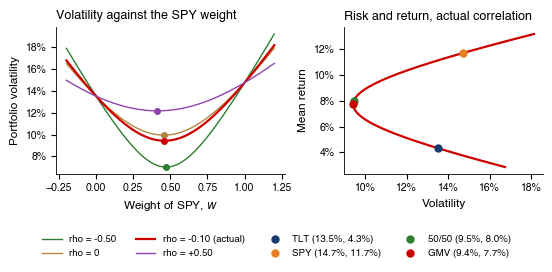

   saved ch4_sem_a1_two_asset


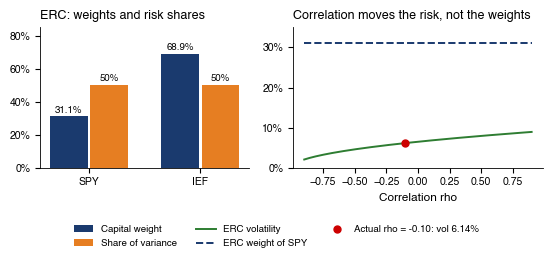

   saved ch4_sem_a3_erc


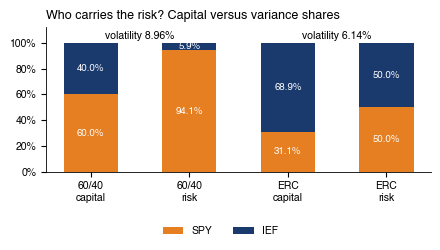

   saved ch4_sem_a4_6040


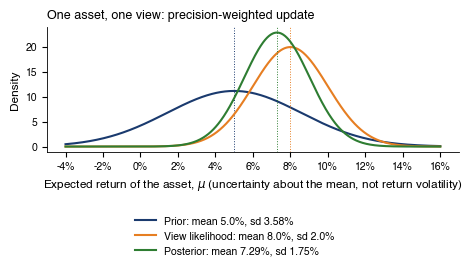

   saved ch4_sem_a5_bl


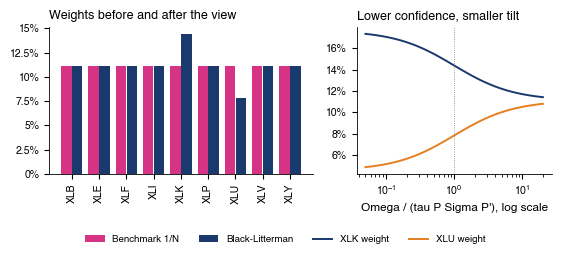

   saved ch4_sem_a6_bl_sectors


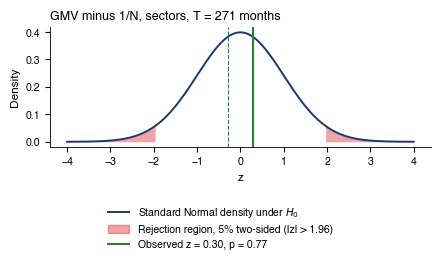

   saved ch4_sem_a7_normal


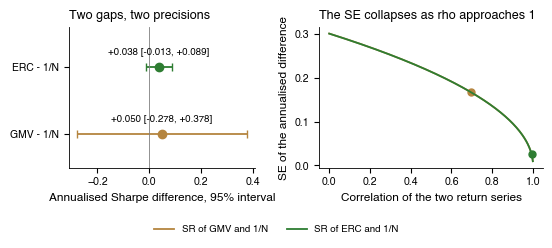

   saved ch4_sem_a8_intervals


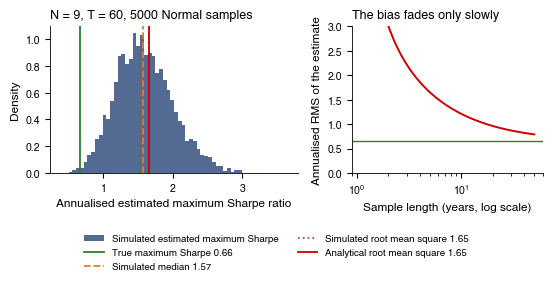

   saved ch4_sem_a9_bias


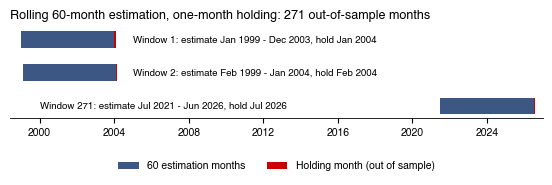

   saved ch4_sem_b1_timeline


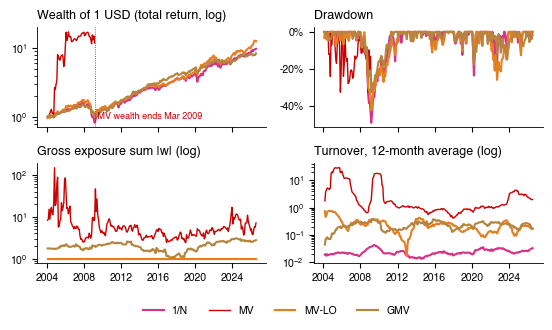

   saved ch4_sem_b1_wealth


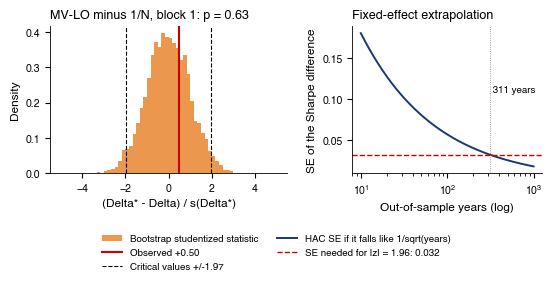

   saved ch4_sem_b1_boot


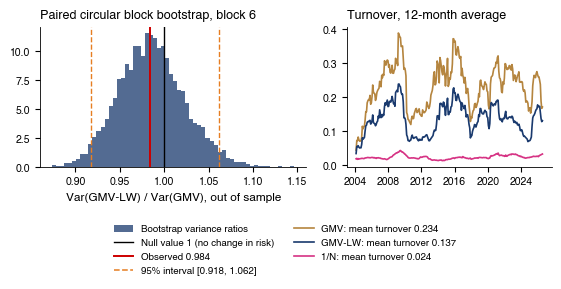

   saved ch4_sem_b2_varratio


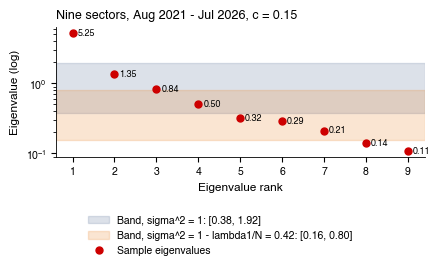

   saved ch4_sem_b2x_eigen


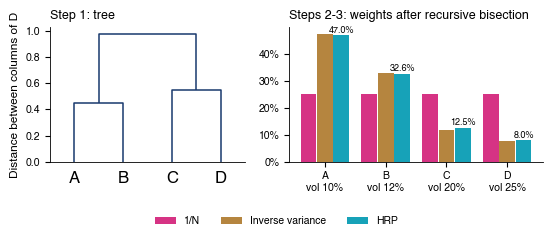

   saved ch4_sem_b3_worked


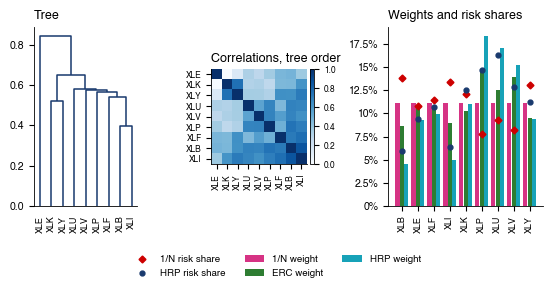

   saved ch4_sem_b3_sectors


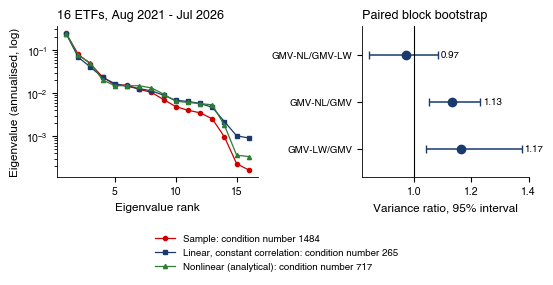

   saved ch4_sem_b4_shrink


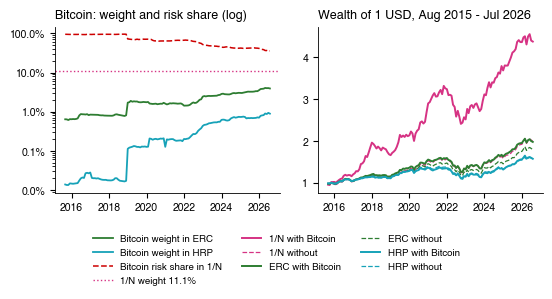

   saved ch4_sem_b5_btc


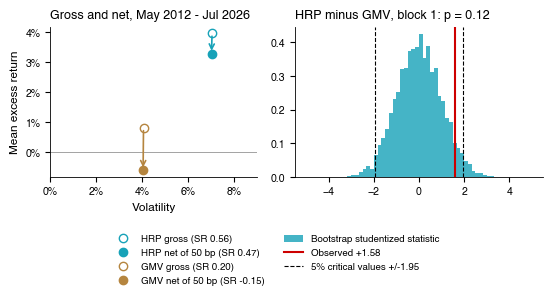

   saved ch4_sem_b6_hrp_gmv


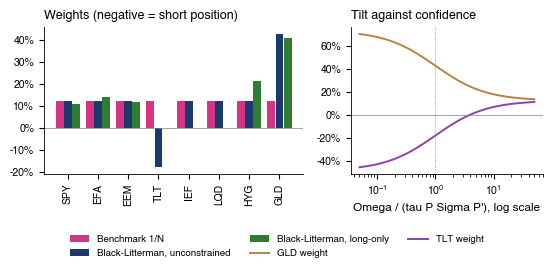

   saved ch4_sem_b7_bl_multi


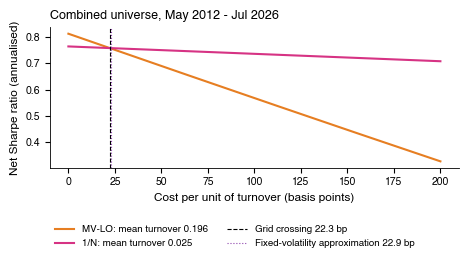

   saved ch4_sem_b8_breakeven


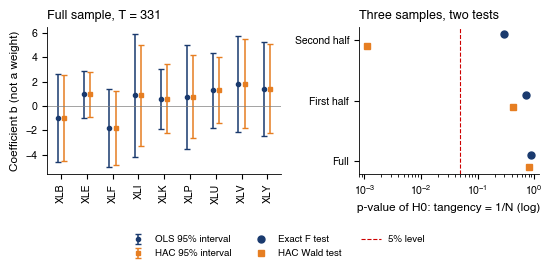

   saved ch4_sem_b9_bj


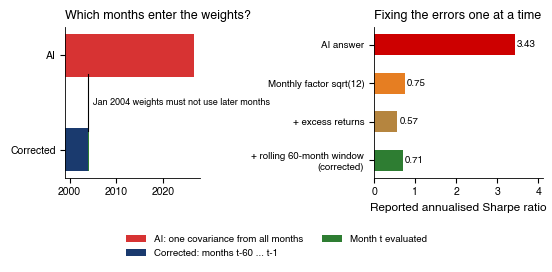

   saved ch4_sem_c2_correction


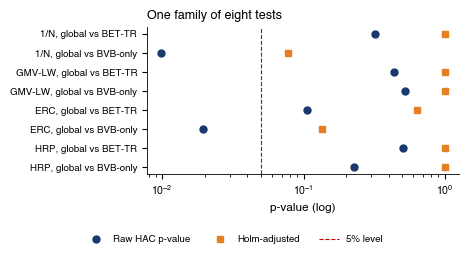

   saved ch4_sem_c1_tests


{
 "setup": {
  "T": 331,
  "first": "1999-01-31",
  "last": "2026-07-31",
  "first_price_date": "1998-12-31",
  "row1": {
   "XLB": -0.037049705654670806,
   "XLK": 0.15900514438122904,
   "XLU": -0.02480286240316798
  },
  "rf1": 0.0034999999999999996,
  "rf_last": 0.0033,
  "mean_rf_ann": 0.019935951661631417,
  "T_multi": 231,
  "multi_first": "2007-05",
  "T_comb": 231
 },
 "A1": {
  "-0.50": {
   "w": 0.4709979900197816,
   "vol": 0.07036642548541928
  },
  "0.00": {
   "w": 0.45655183710972913,
   "vol": 0.09945039639806878
  },
  "-0.10": {
   "w": 0.46050473691596405,
   "vol": 0.09433882133723462
  },
  "0.50": {
   "w": 0.4134311330695538,
   "vol": 0.12157164908732249
  },
  "vol_5050": 0.09470067144232719,
  "mean_5050": 0.080247490628783
 },
 "A3": {
  "w1": 0.3110299703547765,
  "vol": 0.06140067174708435
 },
 "A_5050": {
  "Sw": [
   0.010340054194206406,
   0.001715925816593762
  ],
  "var": 0.006027990005400084,
  "vol": 0.07764013141024481,
  "shares": [
   0.8576701

In [5]:
RES = 'sem4_results.json'
if not os.path.exists(RES):
    urllib.request.urlretrieve('https://raw.githubusercontent.com/danpele/MFM/main/Quantlets/Ch_04/'
                               'MFM_ch4_seminar/sem4_results.json', RES)
with open(RES) as f:
    R = json.load(f)
print(json.dumps(to_py(seminar_charts(R)), indent=1)[:4000])

![ch4_sem_a1_two_asset](./ch4_sem_a1_two_asset.png)

Output: `ch4_sem_a1_two_asset.pdf`

![ch4_sem_a3_erc](./ch4_sem_a3_erc.png)

Output: `ch4_sem_a3_erc.pdf`

![ch4_sem_a4_6040](./ch4_sem_a4_6040.png)

Output: `ch4_sem_a4_6040.pdf`

![ch4_sem_a5_bl](./ch4_sem_a5_bl.png)

Output: `ch4_sem_a5_bl.pdf`

![ch4_sem_a6_bl_sectors](./ch4_sem_a6_bl_sectors.png)

Output: `ch4_sem_a6_bl_sectors.pdf`

![ch4_sem_a7_normal](./ch4_sem_a7_normal.png)

Output: `ch4_sem_a7_normal.pdf`

![ch4_sem_a8_intervals](./ch4_sem_a8_intervals.png)

Output: `ch4_sem_a8_intervals.pdf`

![ch4_sem_a9_bias](./ch4_sem_a9_bias.png)

Output: `ch4_sem_a9_bias.pdf`

![ch4_sem_b1_timeline](./ch4_sem_b1_timeline.png)

Output: `ch4_sem_b1_timeline.pdf`

![ch4_sem_b1_wealth](./ch4_sem_b1_wealth.png)

Output: `ch4_sem_b1_wealth.pdf`

![ch4_sem_b1_boot](./ch4_sem_b1_boot.png)

Output: `ch4_sem_b1_boot.pdf`

![ch4_sem_b2_varratio](./ch4_sem_b2_varratio.png)

Output: `ch4_sem_b2_varratio.pdf`

![ch4_sem_b2x_eigen](./ch4_sem_b2x_eigen.png)

Output: `ch4_sem_b2x_eigen.pdf`

![ch4_sem_b3_worked](./ch4_sem_b3_worked.png)

Output: `ch4_sem_b3_worked.pdf`

![ch4_sem_b3_sectors](./ch4_sem_b3_sectors.png)

Output: `ch4_sem_b3_sectors.pdf`

![ch4_sem_b4_shrink](./ch4_sem_b4_shrink.png)

Output: `ch4_sem_b4_shrink.pdf`

![ch4_sem_b5_btc](./ch4_sem_b5_btc.png)

Output: `ch4_sem_b5_btc.pdf`

![ch4_sem_b6_hrp_gmv](./ch4_sem_b6_hrp_gmv.png)

Output: `ch4_sem_b6_hrp_gmv.pdf`

![ch4_sem_b7_bl_multi](./ch4_sem_b7_bl_multi.png)

Output: `ch4_sem_b7_bl_multi.pdf`

![ch4_sem_b8_breakeven](./ch4_sem_b8_breakeven.png)

Output: `ch4_sem_b8_breakeven.pdf`

![ch4_sem_b9_bj](./ch4_sem_b9_bj.png)

Output: `ch4_sem_b9_bj.pdf`

![ch4_sem_c2_correction](./ch4_sem_c2_correction.png)

Output: `ch4_sem_c2_correction.pdf`

![ch4_sem_c1_tests](./ch4_sem_c1_tests.png)

Output: `ch4_sem_c1_tests.pdf`